## Polygon, 30 bins, inset=markers


Loading Random from: plot_a_files/t0to50_table.txt
Random: 10000 samples
Random: mean complexity_entropy = 24.899

Loading Whole_space from: plot_a_files/compiled_0mut.txt
Whole_space: 5369 samples
Whole_space: mean complexity_entropy = 29.877


/var/folders/yr/bzwkxpcj34x73kc2trlk0h2m0000gn/T/ipykernel_41417/3676739691.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


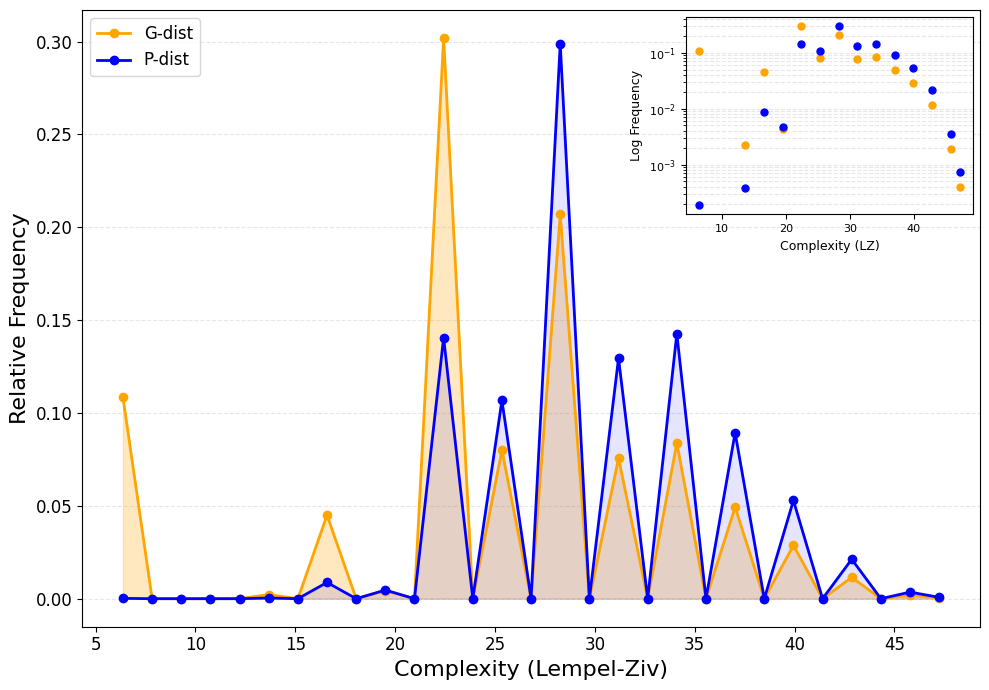

In [79]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ===================================
# Configuration
# ===================================
base_dir = Path("./plot_a_files")
file_path_rand = base_dir / "t0to50_table.txt"
file_path_0_mut = base_dir / "compiled_0mut.txt"
phenotype_length = 50
n_bins = 30
# ===================================

def load_dataset(file_path, name):
    print(f"\nLoading {name} from: {file_path}")

    if not file_path.exists():
        raise FileNotFoundError(f"{file_path} not found")

    df = pd.read_csv(file_path, sep="\t")

    if df.columns[0].startswith("#"):
        df = pd.read_csv(
            file_path,
            sep="\t",
            skiprows=1,
            names=["file_number",
                   "genotype_raw",
                   "phenotype_binary",
                   "complexity_entropy"]
        )

    if "complexity_entropy" not in df.columns:
        raise ValueError(f"'complexity_entropy' not found in {name}")

    df["phenotype_binary"] = df["phenotype_binary"].astype(str)
    df["phenotype_length"] = df["phenotype_binary"].str.len()

    df_filtered = df[df["phenotype_length"] == phenotype_length]

    complexities = df_filtered["complexity_entropy"].astype(float).values
    complexities = complexities[complexities > 0]

    print(f"{name}: {len(complexities)} samples")
    print(f"{name}: mean complexity_entropy = {complexities.mean():.3f}")

    return complexities


# ===================================
# Load data
# ===================================

rand_raw = load_dataset(file_path_rand, "Random")
zero_raw = load_dataset(file_path_0_mut, "Whole_space")

# ===================================
# Linear bins (22 bins)
# ===================================

all_data = np.concatenate([rand_raw, zero_raw])
min_val = all_data.min()
max_val = all_data.max()

bins = np.linspace(min_val, max_val, n_bins)

# ===================================
# PMF normalization (heights sum to 1)
# ===================================

rand_counts, bin_edges = np.histogram(rand_raw, bins=bins, density=False)
zero_counts, _ = np.histogram(zero_raw, bins=bins, density=False)

rand_counts = rand_counts / rand_counts.sum()
zero_counts = zero_counts / zero_counts.sum()

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ===================================
# Main Plot (shaded frequency polygon)
# ===================================

fig, ax = plt.subplots(figsize=(10, 7))

# ---- G-dist ----
ax.plot(bin_centers,
        rand_counts,
        marker='o',
        linewidth=2,
        color="orange",
        label="G-dist")

ax.fill_between(bin_centers,
                rand_counts,
                0,
                color="orange",
                alpha=0.25)

# ---- P-dist ----
ax.plot(bin_centers,
        zero_counts,
        marker='o',
        linewidth=2,
        color="blue",
        label="P-dist")

ax.fill_between(bin_centers,
                zero_counts,
                0,
                color="blue",
                alpha=0.1)

ax.set_xlabel("Complexity (Lempel-Ziv)", fontsize=16)
ax.set_ylabel("Relative Frequency", fontsize=16)

ax.legend(fontsize=12, loc="upper left")
ax.tick_params(labelsize=12)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

# =========================
# Inset Panel (log-y, markers-only)
# =========================
ax_inset = inset_axes(ax, width="32%", height="32%", loc="upper right")

# mask nonzero bins
mask_rand = rand_counts > 0
mask_zero = zero_counts > 0

# plot markers only (no connecting lines)
ax_inset.plot(bin_centers[mask_rand],
              rand_counts[mask_rand],
              marker='o',
              linestyle='',
              markersize=5,
              color="orange",
              label="G-dist")

ax_inset.plot(bin_centers[mask_zero],
              zero_counts[mask_zero],
              marker='o',
              linestyle='',
              markersize=5,
              color="blue",
              label="P-dist")

ax_inset.set_yscale("log")
ax_inset.set_xlabel("Complexity (LZ)", fontsize=9)
ax_inset.set_ylabel("Log Frequency", fontsize=9)
ax_inset.tick_params(labelsize=8)
ax_inset.grid(which="both", axis="y", alpha=0.3, linestyle="--")

# ===================================

plt.tight_layout()
plt.show()

### inset = sticks


Loading Random from: plot_a_files/t0to50_table.txt
Random: 10000 samples
Random: mean complexity_entropy = 24.899

Loading Whole_space from: plot_a_files/compiled_0mut.txt
Whole_space: 5369 samples
Whole_space: mean complexity_entropy = 29.877


/var/folders/yr/bzwkxpcj34x73kc2trlk0h2m0000gn/T/ipykernel_41417/4254067163.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


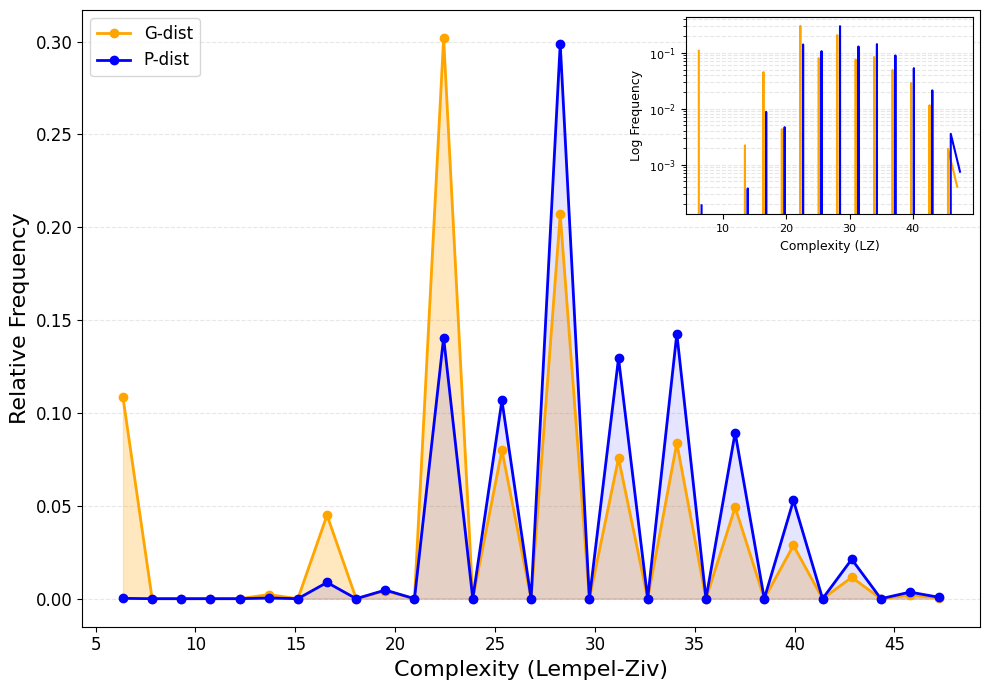

In [85]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ===================================
# Configuration
# ===================================
base_dir = Path("./plot_a_files")
file_path_rand = base_dir / "t0to50_table.txt"
file_path_0_mut = base_dir / "compiled_0mut.txt"
phenotype_length = 50
n_bins = 30
# ===================================

def load_dataset(file_path, name):
    print(f"\nLoading {name} from: {file_path}")

    if not file_path.exists():
        raise FileNotFoundError(f"{file_path} not found")

    df = pd.read_csv(file_path, sep="\t")

    if df.columns[0].startswith("#"):
        df = pd.read_csv(
            file_path,
            sep="\t",
            skiprows=1,
            names=["file_number",
                   "genotype_raw",
                   "phenotype_binary",
                   "complexity_entropy"]
        )

    if "complexity_entropy" not in df.columns:
        raise ValueError(f"'complexity_entropy' not found in {name}")

    df["phenotype_binary"] = df["phenotype_binary"].astype(str)
    df["phenotype_length"] = df["phenotype_binary"].str.len()

    df_filtered = df[df["phenotype_length"] == phenotype_length]

    complexities = df_filtered["complexity_entropy"].astype(float).values
    complexities = complexities[complexities > 0]

    print(f"{name}: {len(complexities)} samples")
    print(f"{name}: mean complexity_entropy = {complexities.mean():.3f}")

    return complexities


# ===================================
# Load data
# ===================================

rand_raw = load_dataset(file_path_rand, "Random")
zero_raw = load_dataset(file_path_0_mut, "Whole_space")

# ===================================
# Linear bins (22 bins)
# ===================================

all_data = np.concatenate([rand_raw, zero_raw])
min_val = all_data.min()
max_val = all_data.max()

bins = np.linspace(min_val, max_val, n_bins)

# ===================================
# PMF normalization (heights sum to 1)
# ===================================

rand_counts, bin_edges = np.histogram(rand_raw, bins=bins, density=False)
zero_counts, _ = np.histogram(zero_raw, bins=bins, density=False)

rand_counts = rand_counts / rand_counts.sum()
zero_counts = zero_counts / zero_counts.sum()

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ===================================
# Main Plot (shaded frequency polygon)
# ===================================

fig, ax = plt.subplots(figsize=(10, 7))

# ---- G-dist ----
ax.plot(bin_centers,
        rand_counts,
        marker='o',
        linewidth=2,
        color="orange",
        label="G-dist")

ax.fill_between(bin_centers,
                rand_counts,
                0,
                color="orange",
                alpha=0.25)

# ---- P-dist ----
ax.plot(bin_centers,
        zero_counts,
        marker='o',
        linewidth=2,
        color="blue",
        label="P-dist")

ax.fill_between(bin_centers,
                zero_counts,
                0,
                color="blue",
                alpha=0.1)

ax.set_xlabel("Complexity (Lempel-Ziv)", fontsize=16)
ax.set_ylabel("Relative Frequency", fontsize=16)

ax.legend(fontsize=12, loc="upper left")
ax.tick_params(labelsize=12)
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

# ===================================
# Inset Panel (log–y, slight x-offset)
# ===================================

ax_inset = inset_axes(ax, width="32%", height="32%", loc="upper right")

# Compute small horizontal offset relative to bin spacing
bin_spacing = bin_centers[1] - bin_centers[0]
offset = 0.15 * bin_spacing   # adjust 0.10–0.20 if needed

# Plot shifted curves
ax_inset.plot(bin_centers - offset,
              rand_counts,
              linewidth=1.5,
              color="orange")

ax_inset.plot(bin_centers + offset,
              zero_counts,
              linewidth=1.5,
              color="blue")

ax_inset.set_yscale("log")

ax_inset.set_xlabel("Complexity (LZ)", fontsize=9)
ax_inset.set_ylabel("Log Frequency", fontsize=9)

ax_inset.tick_params(labelsize=8)
ax_inset.grid(which="both", axis="y", alpha=0.3, linestyle="--")

# ===================================

plt.tight_layout()
plt.show()

## Raw Data Histogram


Loading Random from: plot_a_files/t0to50_table.txt
Random columns: ['file_number', 'genotype_raw', 'phenotype_binary', 'complexity_entropy']
Random: 10000 samples
Random: mean complexity_entropy = 24.899

Loading Whole_space from: plot_a_files/compiled_0mut.txt
Whole_space columns: ['file_number', 'genotype_raw', 'phenotype_binary', 'complexity_entropy']
Whole_space: 5369 samples
Whole_space: mean complexity_entropy = 29.877

Data range: 5.64 → 47.97
Bin width = 2
Number of bins = 22


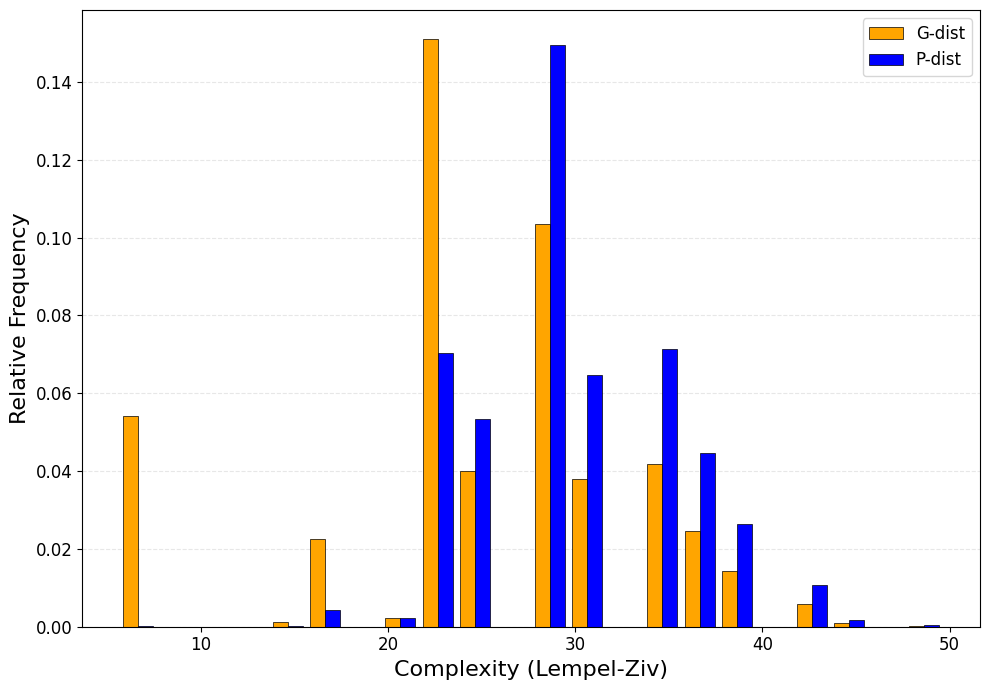

In [67]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ===================================
# Configuration
# ===================================
base_dir = Path("./plot_a_files")
file_path_rand = base_dir / "t0to50_table.txt"
file_path_0_mut = base_dir / "compiled_0mut.txt"
phenotype_length = 50
# ===================================

def load_dataset(file_path, name):
    print(f"\nLoading {name} from: {file_path}")

    if not file_path.exists():
        raise FileNotFoundError(f"{file_path} not found")

    df = pd.read_csv(file_path, sep="\t")

    print(f"{name} columns: {df.columns.tolist()}")

    # If header line commented
    if df.columns[0].startswith("#"):
        df = pd.read_csv(
            file_path,
            sep="\t",
            skiprows=1,
            names=["file_number",
                   "genotype_raw",
                   "phenotype_binary",
                   "complexity_entropy"]
        )
        print(f"{name} re-read with explicit columns")

    # Enforce correct column usage
    if "complexity_entropy" not in df.columns:
        raise ValueError(f"'complexity_entropy' not found in {name}")

    df["phenotype_binary"] = df["phenotype_binary"].astype(str)
    df["phenotype_length"] = df["phenotype_binary"].str.len()

    df_filtered = df[df["phenotype_length"] == phenotype_length]

    complexities = df_filtered["complexity_entropy"].astype(float).values
    complexities = complexities[complexities > 0]

    print(f"{name}: {len(complexities)} samples")
    print(f"{name}: mean complexity_entropy = {complexities.mean():.3f}")

    return complexities


# Load fresh
rand_raw = load_dataset(file_path_rand, "Random")
zero_raw = load_dataset(file_path_0_mut, "Whole_space")

# ===================================
# Histogram settings
# ===================================
bin_width = 2

min_val = min(rand_raw.min(), zero_raw.min())
max_val = max(rand_raw.max(), zero_raw.max())

bins = np.arange(min_val, max_val + bin_width, bin_width)

print(f"\nData range: {min_val:.2f} → {max_val:.2f}")
print(f"Bin width = {bin_width}")
print(f"Number of bins = {len(bins)-1}")

# Compute densities
rand_counts, bin_edges = np.histogram(rand_raw, bins=bins, density=True)
zero_counts, _ = np.histogram(zero_raw, bins=bins, density=True)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ===================================
# Plot
# ===================================
fig, ax = plt.subplots(figsize=(10, 7))

bar_width = bin_width * 0.4

ax.bar(bin_centers - bar_width/2,
       rand_counts,
       width=bar_width,
       color="orange",
       edgecolor="black",
       linewidth=0.5,
       label="G-dist")

ax.bar(bin_centers + bar_width/2,
       zero_counts,
       width=bar_width,
       color="blue",
       edgecolor="black",
       linewidth=0.5,
       label="P-dist")

ax.set_xlabel("Complexity (Lempel-Ziv)", fontsize=16)
ax.set_ylabel("Relative Frequency", fontsize=16)

ax.legend(fontsize=12, loc="upper right")
ax.tick_params(labelsize=12)

ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Smoothing Binned Histograms


Reading rand from: plot_a_files/t0to50_table.txt
✓ Successfully loaded 10000 rows

Reading 0_mut from: plot_a_files/compiled_0mut.txt
✓ Successfully loaded 5369 rows

Proceeding with 2 valid datasets...
rand: 10000 samples, mean=24.90
0_mut: 5369 samples, mean=29.88


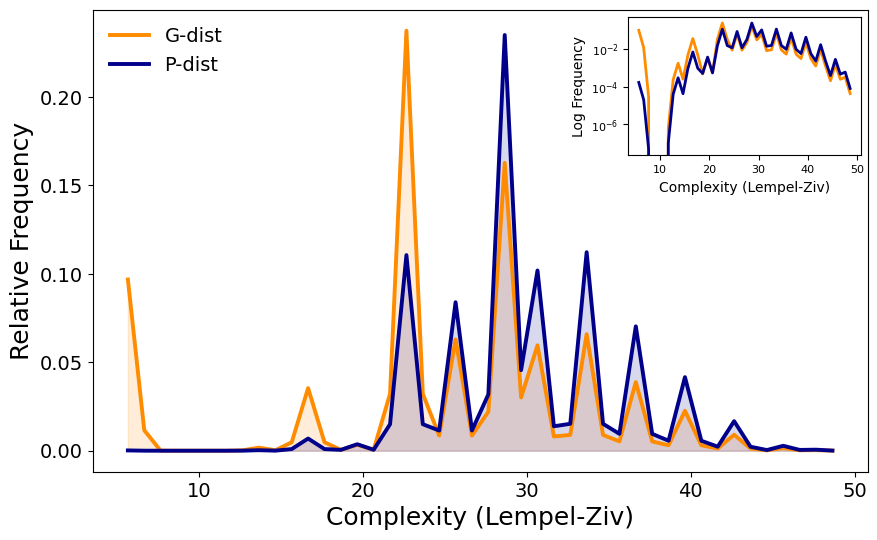


Plot saved to: plots/Plot_A_Circ.png


In [44]:
#!/usr/bin/env python3
"""
Version 4: Smooth density curves using Gaussian filtering
Creates publication-quality smooth curves
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ========== CONFIGURATION ==========
base_dir = './plot_a_files'
output_dir = './plots'
output_name = 'Plot_A_Circ.png'
phenotype_length = 50
num_bins = 45
smooth_sigma = 0.5  # controls smoothness of curves
# ===================================

file_path_rand = Path(base_dir) / "t0to50_table.txt"
file_path_0_mut = Path(base_dir) / "compiled_0mut.txt"

def read_and_debug_file(file_path, dataset_name):
    """Read file and handle different header formats"""
    print(f"\nReading {dataset_name} from: {file_path}")
    
    if not os.path.exists(file_path):
        print(f"ERROR: File not found: {file_path}")
        return None
    
    try:
        df = pd.read_csv(file_path, sep='\t')
        print(f"✓ Successfully loaded {len(df)} rows")
        
        first_col = df.columns[0]
        if first_col.startswith('#'):
            df = pd.read_csv(file_path, sep='\t', skiprows=1, 
                           names=['file_number', 'genotype_raw', 'phenotype_binary', 'complexity_entropy'])
            print(f"✓ Re-read with proper column names: {len(df)} rows")
        
        return df
        
    except Exception as e:
        print(f"ERROR reading {dataset_name}: {e}")
        return None

# Read datasets
df_rand = read_and_debug_file(file_path_rand, "rand")
df_0_mut = read_and_debug_file(file_path_0_mut, "0_mut")

datasets = [
    (df_rand, "rand"),
    (df_0_mut, "0_mut")
]

valid_datasets = [(df, name) for df, name in datasets if df is not None]

if len(valid_datasets) == 0:
    print("ERROR: No valid datasets found. Exiting.")
    raise ValueError("No valid datasets found")

print(f"\nProceeding with {len(valid_datasets)} valid datasets...")

def process_dataset(df, name):
    """Process a single dataset"""
    df['phenotype_binary'] = df['phenotype_binary'].astype(str)
    df['phenotype_length'] = df['phenotype_binary'].str.len()
    df_filtered = df[df['phenotype_length'] == phenotype_length]
    
    complexities = df_filtered['complexity_entropy']
    mean_complexity = complexities.mean()
    
    print(f"{name}: {len(complexities)} samples, mean={mean_complexity:.2f}")
    
    return complexities, len(complexities), mean_complexity

# Process datasets
processed_data = []
for df, name in valid_datasets:
    try:
        complexities, count, mean_val = process_dataset(df, name)
        processed_data.append((complexities, count, mean_val, name))
    except Exception as e:
        print(f"ERROR processing {name}: {e}")

# Calculate bins from all data
all_complexities = np.concatenate([data[0] for data in processed_data])
bins = np.arange(all_complexities.min() - 0.5,
                 all_complexities.max() + 1.5, 1.0)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

def density_curve(data, bins, sigma):
    """Create smooth density curve using Gaussian filtering"""
    hist, _ = np.histogram(data, bins=bins, density=False)
    hist = hist / len(data)  # normalize to relative frequency
    hist = gaussian_filter1d(hist, sigma=sigma)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    return bin_centers, hist

# Set up colors
colors = {
    'rand': '#FF8C00',
    '0_mut': 'darkblue'
}

labels = {
    'rand': 'G-dist',
    '0_mut': 'P-dist'
}

# Create output directory
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for complexities, count, mean_val, name in processed_data:
    x, y = density_curve(complexities, bins, smooth_sigma)
    ax.plot(x, y, lw=2.8, color=colors[name], label=labels[name])
    ax.fill_between(x, y, color=colors[name], alpha=0.15)

#ax.set_title('Version 4: Smooth Density Curves (Gaussian Filtered)', fontsize=16, pad=15)
ax.set_xlabel('Complexity (Lempel-Ziv)', fontsize=18)
ax.set_ylabel('Relative Frequency', fontsize=18)
ax.legend(frameon=False, fontsize=14, loc='upper left')
ax.tick_params(labelsize=14)

# Add inset with log-scale y-axis
axins = inset_axes(ax, width="30%", height="30%", loc='upper right')

for complexities, count, mean_val, name in processed_data:
    x, y = density_curve(complexities, bins, smooth_sigma)
    axins.plot(x, y, lw=2.0, color=colors[name])

axins.set_yscale('log')
axins.set_xlabel('Complexity (Lempel-Ziv)', fontsize=10)
axins.set_ylabel('Log Frequency', fontsize=10)
axins.tick_params(labelsize=8)

# Save the plot
output_path = Path(output_dir) / output_name
plt.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"\nPlot saved to: {output_path}")

## KDE

aggregated data


--- RAW STATS ---
G raw N = 10000
P raw N = 5369
G mean = 24.8985
P mean = 29.8766
Difference (P - G) = 4.9780

--- BANDWIDTHS (Aggregated) ---

G-dist:
  Aggregated support size = 14
  Silverman bandwidth = 0.743408

P-dist:
  Aggregated support size = 14
  Silverman bandwidth = 0.742172


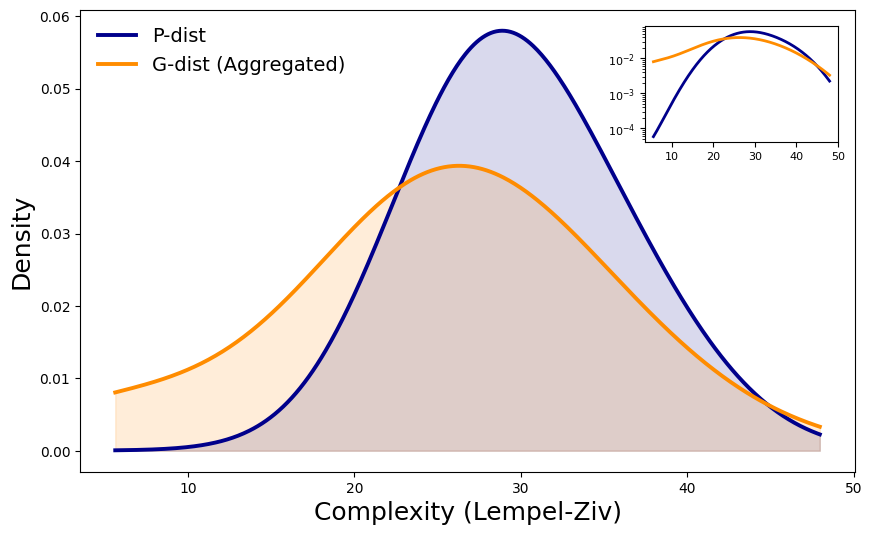


Saved: Plot_A_Circ_AGG.png


In [48]:
#!/usr/bin/env python3
"""
Circadian Rhythm Model — AGGREGATED KDE
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ========== CONFIGURATION ==========
base_dir = './plot_a_files'
output_dir = './plots'
output_name = 'Plot_A_Circ_AGG.png'
phenotype_length = 50
# ===================================

file_path_rand = Path(base_dir) / "t0to50_table.txt"
file_path_0_mut = Path(base_dir) / "compiled_0mut.txt"

# ---------- Load ----------
df_rand = pd.read_csv(file_path_rand, sep='\t')
df_0_mut = pd.read_csv(file_path_0_mut, sep='\t')

# ---------- Filter ----------
def process_dataset(df):
    df['phenotype_binary'] = df['phenotype_binary'].astype(str)
    df = df[df['phenotype_binary'].str.len() == phenotype_length]
    return df['complexity_entropy'].values

g_raw = process_dataset(df_rand)
p_raw = process_dataset(df_0_mut)

print("\n--- RAW STATS ---")
print(f"G raw N = {len(g_raw)}")
print(f"P raw N = {len(p_raw)}")
print(f"G mean = {g_raw.mean():.4f}")
print(f"P mean = {p_raw.mean():.4f}")
print(f"Difference (P - G) = {p_raw.mean() - g_raw.mean():.4f}")

# ---------- Aggregate ----------
def kde_aggregated(data, name):

    unique_vals, counts = np.unique(data, return_counts=True)
    weights = counts / counts.sum()

    kde = gaussian_kde(unique_vals, weights=weights, bw_method='silverman')

    print(f"\n{name}:")
    print(f"  Aggregated support size = {len(unique_vals)}")
    print(f"  Silverman bandwidth = {kde.factor:.6f}")

    x = np.linspace(unique_vals.min(), unique_vals.max(), 500)
    y = kde(x)

    return x, y

print("\n--- BANDWIDTHS (Aggregated) ---")
x_g, y_g = kde_aggregated(g_raw, "G-dist")
x_p, y_p = kde_aggregated(p_raw, "P-dist")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(x_p, y_p, lw=2.8, color="darkblue", label="P-dist")
ax.fill_between(x_p, y_p, color="darkblue", alpha=0.15)

ax.plot(x_g, y_g, lw=2.8, color="#FF8C00", label="G-dist (Aggregated)")
ax.fill_between(x_g, y_g, color="#FF8C00", alpha=0.15)

ax.set_xlabel("Complexity (Lempel-Ziv)", fontsize=18)
ax.set_ylabel("Density", fontsize=18)
ax.legend(frameon=False, fontsize=14, loc="upper left")

# ---- Inset ----
axins = inset_axes(ax, width="25%", height="25%", loc="upper right", borderpad=1.2)
axins.plot(x_p, y_p, lw=2.0, color="darkblue")
axins.plot(x_g, y_g, lw=2.0, color="#FF8C00")
axins.set_yscale("log")
axins.tick_params(labelsize=8)

Path(output_dir).mkdir(exist_ok=True)
plt.savefig(Path(output_dir)/output_name, dpi=200, bbox_inches='tight')
plt.show()

print(f"\nSaved: {output_name}")


## raw data


Reading rand from: plot_a_files/t0to50_table.txt
✓ Successfully loaded 10000 rows

Reading 0_mut from: plot_a_files/compiled_0mut.txt
✓ Successfully loaded 5369 rows

Proceeding with 2 valid datasets...
rand: 10000 samples, mean=24.90
0_mut: 5369 samples, mean=29.88

Mean Complexity:
  G-dist (rand): 24.90
  P-dist (0-mut): 29.88
  Difference (P - G): 4.98

KDE Bandwidth Information:
G-dist:
  N raw = 10000
  Silverman bandwidth = 0.167876
P-dist:
  N raw = 5369
  Silverman bandwidth = 0.190112


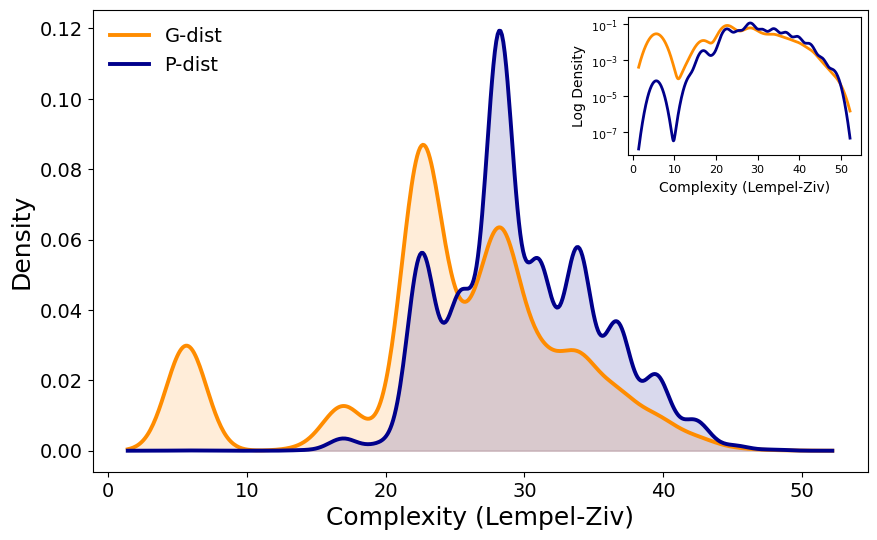


Plot saved to: plots/Plot_A_Circ.png


In [50]:
#!/usr/bin/env python3
"""
Plot LZ Complexity Distribution for Circadian Rhythm Model
Shows G-dist (rand) vs P-dist (0-mut) using Kernel Density Estimation with Silverman's rule
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ========== CONFIGURATION ==========
base_dir = './plot_a_files'
output_dir = './plots'
output_name = 'Plot_A_Circ.png'
phenotype_length = 50
# ===================================

file_path_rand = Path(base_dir) / "t0to50_table.txt"
file_path_0_mut = Path(base_dir) / "compiled_0mut.txt"

def read_and_debug_file(file_path, dataset_name):
    """Read file and handle different header formats"""
    print(f"\nReading {dataset_name} from: {file_path}")
    
    if not os.path.exists(file_path):
        print(f"ERROR: File not found: {file_path}")
        return None
    
    try:
        df = pd.read_csv(file_path, sep='\t')
        print(f"✓ Successfully loaded {len(df)} rows")
        
        first_col = df.columns[0]
        if first_col.startswith('#'):
            df = pd.read_csv(file_path, sep='\t', skiprows=1, 
                           names=['file_number', 'genotype_raw', 'phenotype_binary', 'complexity_entropy'])
            print(f"✓ Re-read with proper column names: {len(df)} rows")
        
        return df
        
    except Exception as e:
        print(f"ERROR reading {dataset_name}: {e}")
        return None

# Read datasets
df_rand = read_and_debug_file(file_path_rand, "rand")
df_0_mut = read_and_debug_file(file_path_0_mut, "0_mut")

datasets = [
    (df_rand, "rand"),
    (df_0_mut, "0_mut")
]

valid_datasets = [(df, name) for df, name in datasets if df is not None]

if len(valid_datasets) == 0:
    print("ERROR: No valid datasets found. Exiting.")
    raise ValueError("No valid datasets found")

print(f"\nProceeding with {len(valid_datasets)} valid datasets...")

def process_dataset(df, name):
    """Process a single dataset"""
    df['phenotype_binary'] = df['phenotype_binary'].astype(str)
    df['phenotype_length'] = df['phenotype_binary'].str.len()
    df_filtered = df[df['phenotype_length'] == phenotype_length]
    
    complexities = df_filtered['complexity_entropy'].values
    mean_complexity = complexities.mean()
    
    print(f"{name}: {len(complexities)} samples, mean={mean_complexity:.2f}")
    
    return complexities, mean_complexity

# ===============================
# KDE function (RAW)
# ===============================
def kde_curve(data, name=None):

    n_raw = len(data)
    kde = gaussian_kde(data, bw_method='silverman')

    if name:
        print(f"{name}:")
        print(f"  N raw = {n_raw}")
        print(f"  Silverman bandwidth = {kde.factor:.6f}")

    x_min, x_max = data.min(), data.max()
    x_range = x_max - x_min
    x = np.linspace(x_min - 0.1 * x_range,
                    x_max + 0.1 * x_range,
                    500)
    y = kde(x)

    return x, y


# Process datasets
datasets_processed = {}
mean_complexities = {}

for df, name in valid_datasets:
    try:
        complexities, mean_val = process_dataset(df, name)
        datasets_processed[name] = complexities
        mean_complexities[name] = mean_val
    except Exception as e:
        print(f"ERROR processing {name}: {e}")

# Print mean complexity comparison
print(f"\nMean Complexity:")
if 'rand' in mean_complexities:
    print(f"  G-dist (rand): {mean_complexities['rand']:.2f}")
if '0_mut' in mean_complexities:
    print(f"  P-dist (0-mut): {mean_complexities['0_mut']:.2f}")
if 'rand' in mean_complexities and '0_mut' in mean_complexities:
    diff = mean_complexities['0_mut'] - mean_complexities['rand']
    print(f"  Difference (P - G): {diff:.2f}")

# Set up colors
colors = {
    'rand': '#FF8C00',
    '0_mut': 'darkblue'
}

labels = {
    'rand': 'G-dist',
    '0_mut': 'P-dist'
}

# Create output directory
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

print("\nKDE Bandwidth Information:")
# ---- Main plot ----
for name, complexities in datasets_processed.items():
    x, y = kde_curve(complexities, name=labels[name])
    ax.plot(x, y, lw=2.8, color=colors[name], label=labels[name])
    ax.fill_between(x, y, color=colors[name], alpha=0.15)

ax.set_xlabel('Complexity (Lempel-Ziv)', fontsize=18)
ax.set_ylabel('Density', fontsize=18)
ax.legend(frameon=False, fontsize=14, loc='upper left')
ax.tick_params(labelsize=14)

# ---- Inset (log y) ----
axins = inset_axes(ax, width="30%", height="30%", loc='upper right')

for name, complexities in datasets_processed.items():
    x, y = kde_curve(complexities)
    axins.plot(x, y, lw=2.0, color=colors[name])

axins.set_yscale('log')
axins.set_xlabel('Complexity (Lempel-Ziv)', fontsize=10)
axins.set_ylabel('Log Density', fontsize=10)
axins.tick_params(labelsize=8)

# Save the plot
output_path = Path(output_dir) / output_name
plt.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"\nPlot saved to: {output_path}")

## Final: Raw Data Bandwidth 1.5


Reading rand from: plot_a_files/t0to50_table.txt
✓ Successfully loaded 10000 rows

Reading 0_mut from: plot_a_files/compiled_0mut.txt
✓ Successfully loaded 5369 rows

Proceeding with 2 valid datasets...
rand: 10000 samples, mean=24.90
0_mut: 5369 samples, mean=29.88

Mean Complexity:
  G-dist (rand): 24.90
  P-dist (0-mut): 29.88
  Difference (P - G): 4.98

KDE Bandwidth Information:
G-dist:
  Silverman factor = 0.167876
  Adjusted factor  = 0.251813
P-dist:
  Silverman factor = 0.190112
  Adjusted factor  = 0.285168


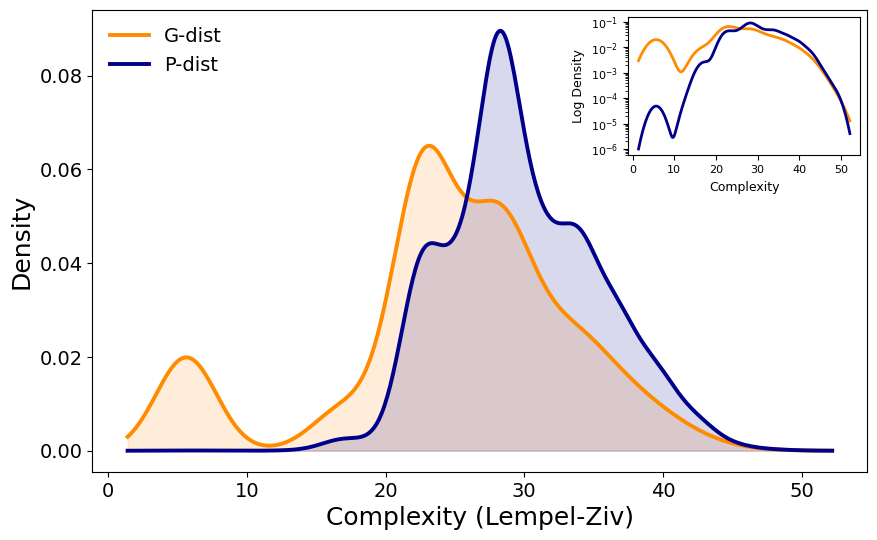


Plot saved to: plots/Plot_A_Circ.png


In [60]:
#!/usr/bin/env python3
"""
Plot LZ Complexity Distribution for Circadian Rhythm Model
Shows G-dist (rand) vs P-dist (0-mut) using Kernel Density Estimation
with DOUBLE Silverman's bandwidth (2 × Silverman).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

bandwidth_multiplier = 1.5

# ========== CONFIGURATION ==========
base_dir = './plot_a_files'
output_dir = './plots'
output_name = 'Plot_A_Circ.png'
phenotype_length = 50
# ===================================

file_path_rand = Path(base_dir) / "t0to50_table.txt"
file_path_0_mut = Path(base_dir) / "compiled_0mut.txt"

def read_and_debug_file(file_path, dataset_name):
    """Read file and handle different header formats"""
    print(f"\nReading {dataset_name} from: {file_path}")
    
    if not os.path.exists(file_path):
        print(f"ERROR: File not found: {file_path}")
        return None
    
    try:
        df = pd.read_csv(file_path, sep='\t')
        print(f"✓ Successfully loaded {len(df)} rows")
        
        first_col = df.columns[0]
        if first_col.startswith('#'):
            df = pd.read_csv(
                file_path,
                sep='\t',
                skiprows=1,
                names=['file_number', 'genotype_raw',
                       'phenotype_binary', 'complexity_entropy']
            )
            print(f"✓ Re-read with proper column names: {len(df)} rows")
        
        return df
        
    except Exception as e:
        print(f"ERROR reading {dataset_name}: {e}")
        return None

# Read datasets
df_rand = read_and_debug_file(file_path_rand, "rand")
df_0_mut = read_and_debug_file(file_path_0_mut, "0_mut")

datasets = [
    (df_rand, "rand"),
    (df_0_mut, "0_mut")
]

valid_datasets = [(df, name) for df, name in datasets if df is not None]

if len(valid_datasets) == 0:
    raise ValueError("No valid datasets found")

print(f"\nProceeding with {len(valid_datasets)} valid datasets...")

def process_dataset(df, name):
    """Process a single dataset"""
    df['phenotype_binary'] = df['phenotype_binary'].astype(str)
    df['phenotype_length'] = df['phenotype_binary'].str.len()
    df_filtered = df[df['phenotype_length'] == phenotype_length]
    
    complexities = df_filtered['complexity_entropy'].values
    mean_complexity = complexities.mean()
    
    print(f"{name}: {len(complexities)} samples, mean={mean_complexity:.2f}")
    
    return complexities, mean_complexity


# ===============================
# KDE function (DOUBLE Silverman bandwidth)
# ===============================
def kde_curve(data, name=None):

    n_raw = len(data)

    kde = gaussian_kde(data, bw_method='silverman')
    silverman_factor = kde.factor

    # Apply multiplier
    kde.set_bandwidth(bw_method=silverman_factor * bandwidth_multiplier)

    if name:
        print(f"{name}:")
        print(f"  Silverman factor = {silverman_factor:.6f}")
        print(f"  Adjusted factor  = {kde.factor:.6f}")

    x_min, x_max = data.min(), data.max()
    x_range = x_max - x_min

    x = np.linspace(
        x_min - 0.1 * x_range,
        x_max + 0.1 * x_range,
        500
    )

    y = kde(x)

    return x, y


# Process datasets
datasets_processed = {}
mean_complexities = {}

for df, name in valid_datasets:
    complexities, mean_val = process_dataset(df, name)
    datasets_processed[name] = complexities
    mean_complexities[name] = mean_val

# Print mean comparison
print("\nMean Complexity:")
if 'rand' in mean_complexities:
    print(f"  G-dist (rand): {mean_complexities['rand']:.2f}")
if '0_mut' in mean_complexities:
    print(f"  P-dist (0-mut): {mean_complexities['0_mut']:.2f}")
if 'rand' in mean_complexities and '0_mut' in mean_complexities:
    diff = mean_complexities['0_mut'] - mean_complexities['rand']
    print(f"  Difference (P - G): {diff:.2f}")

# Colors
colors = {
    'rand': '#FF8C00',
    '0_mut': 'darkblue'
}

labels = {
    'rand': 'G-dist',
    '0_mut': 'P-dist'
}

# Create output directory
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

print("\nKDE Bandwidth Information:")

# ---- Main plot ----
for name, complexities in datasets_processed.items():
    x, y = kde_curve(complexities, name=labels[name])
    ax.plot(x, y, lw=2.8, color=colors[name], label=labels[name])
    ax.fill_between(x, y, color=colors[name], alpha=0.15)

ax.set_xlabel('Complexity (Lempel-Ziv)', fontsize=18)
ax.set_ylabel('Density', fontsize=18)
#ax.set_title(f'Bandwidth= {bandwidth_multiplier:.1f} × Silverman', fontsize=18)
ax.legend(frameon=False, fontsize=14, loc='upper left')
ax.tick_params(labelsize=14)

# ---- Inset (log y) ----
axins = inset_axes(ax, width="30%", height="30%", loc='upper right')

for name, complexities in datasets_processed.items():
    x, y = kde_curve(complexities)
    axins.plot(x, y, lw=2.0, color=colors[name])

axins.set_yscale('log')
axins.set_xlabel('Complexity', fontsize=9)
axins.set_ylabel('Log Density', fontsize=9)
axins.tick_params(labelsize=8)

# Save
output_path = Path(output_dir) / output_name
plt.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to: {output_path}")


## 2 Axes


Reading rand from: plot_a_files/t0to50_table.txt
✓ Successfully loaded 10000 rows

Reading 0_mut from: plot_a_files/compiled_0mut.txt
✓ Successfully loaded 5369 rows

Proceeding with 2 valid datasets...
rand: 10000 samples, mean=24.90
0_mut: 5369 samples, mean=29.88

Mean Complexity:
  G-dist (rand): 24.90
  P-dist (0-mut): 29.88
  Difference (P - G): 4.98

KDE Bandwidth Information:
G-dist:
  Silverman factor = 0.167876
  Adjusted factor  = 0.335751
P-dist:
  Silverman factor = 0.190112
  Adjusted factor  = 0.380224


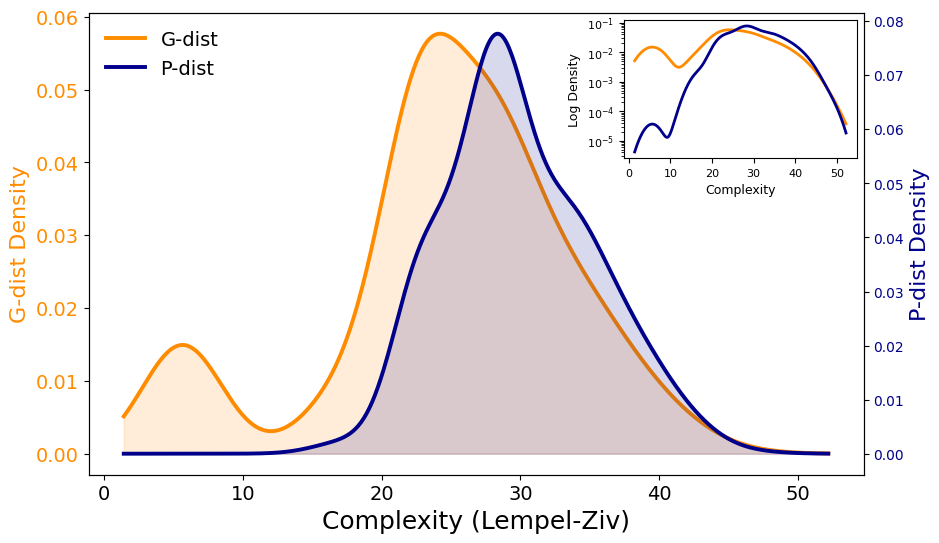


Plot saved to: plots/Plot_A_Circ.png


In [62]:
#!/usr/bin/env python3
"""
Plot LZ Complexity Distribution for Circadian Rhythm Model
Shows G-dist (rand) vs P-dist (0-mut) using Kernel Density Estimation
with DOUBLE Silverman's bandwidth (2 × Silverman).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

bandwidth_multiplier = 2

# ========== CONFIGURATION ==========
base_dir = './plot_a_files'
output_dir = './plots'
output_name = 'Plot_A_Circ.png'
phenotype_length = 50
# ===================================

file_path_rand = Path(base_dir) / "t0to50_table.txt"
file_path_0_mut = Path(base_dir) / "compiled_0mut.txt"

def read_and_debug_file(file_path, dataset_name):
    """Read file and handle different header formats"""
    print(f"\nReading {dataset_name} from: {file_path}")
    
    if not os.path.exists(file_path):
        print(f"ERROR: File not found: {file_path}")
        return None
    
    try:
        df = pd.read_csv(file_path, sep='\t')
        print(f"✓ Successfully loaded {len(df)} rows")
        
        first_col = df.columns[0]
        if first_col.startswith('#'):
            df = pd.read_csv(
                file_path,
                sep='\t',
                skiprows=1,
                names=['file_number', 'genotype_raw',
                       'phenotype_binary', 'complexity_entropy']
            )
            print(f"✓ Re-read with proper column names: {len(df)} rows")
        
        return df
        
    except Exception as e:
        print(f"ERROR reading {dataset_name}: {e}")
        return None

# Read datasets
df_rand = read_and_debug_file(file_path_rand, "rand")
df_0_mut = read_and_debug_file(file_path_0_mut, "0_mut")

datasets = [
    (df_rand, "rand"),
    (df_0_mut, "0_mut")
]

valid_datasets = [(df, name) for df, name in datasets if df is not None]

if len(valid_datasets) == 0:
    raise ValueError("No valid datasets found")

print(f"\nProceeding with {len(valid_datasets)} valid datasets...")

def process_dataset(df, name):
    """Process a single dataset"""
    df['phenotype_binary'] = df['phenotype_binary'].astype(str)
    df['phenotype_length'] = df['phenotype_binary'].str.len()
    df_filtered = df[df['phenotype_length'] == phenotype_length]
    
    complexities = df_filtered['complexity_entropy'].values
    mean_complexity = complexities.mean()
    
    print(f"{name}: {len(complexities)} samples, mean={mean_complexity:.2f}")
    
    return complexities, mean_complexity


# ===============================
# KDE function (DOUBLE Silverman bandwidth)
# ===============================
def kde_curve(data, name=None):

    n_raw = len(data)

    kde = gaussian_kde(data, bw_method='silverman')
    silverman_factor = kde.factor

    # Apply multiplier
    kde.set_bandwidth(bw_method=silverman_factor * bandwidth_multiplier)

    if name:
        print(f"{name}:")
        print(f"  Silverman factor = {silverman_factor:.6f}")
        print(f"  Adjusted factor  = {kde.factor:.6f}")

    x_min, x_max = data.min(), data.max()
    x_range = x_max - x_min

    x = np.linspace(
        x_min - 0.1 * x_range,
        x_max + 0.1 * x_range,
        500
    )

    y = kde(x)

    return x, y


# Process datasets
datasets_processed = {}
mean_complexities = {}

for df, name in valid_datasets:
    complexities, mean_val = process_dataset(df, name)
    datasets_processed[name] = complexities
    mean_complexities[name] = mean_val

# Print mean comparison
print("\nMean Complexity:")
if 'rand' in mean_complexities:
    print(f"  G-dist (rand): {mean_complexities['rand']:.2f}")
if '0_mut' in mean_complexities:
    print(f"  P-dist (0-mut): {mean_complexities['0_mut']:.2f}")
if 'rand' in mean_complexities and '0_mut' in mean_complexities:
    diff = mean_complexities['0_mut'] - mean_complexities['rand']
    print(f"  Difference (P - G): {diff:.2f}")

# Colors
colors = {
    'rand': '#FF8C00',
    '0_mut': 'darkblue'
}

labels = {
    'rand': 'G-dist',
    '0_mut': 'P-dist'
}

# Create output directory
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

print("\nKDE Bandwidth Information:")

# ---- Plot each dataset on its own axis ----
for name, complexities in datasets_processed.items():
    x, y = kde_curve(complexities, name=labels[name])

    if name == "rand":  # G-dist
        ax1.plot(x, y, lw=2.8, color=colors[name], label=labels[name])
        ax1.fill_between(x, y, color=colors[name], alpha=0.15)
    else:  # 0_mut → P-dist
        ax2.plot(x, y, lw=2.8, color=colors[name], label=labels[name])
        ax2.fill_between(x, y, color=colors[name], alpha=0.15)

# Axis labels
ax1.set_xlabel('Complexity (Lempel-Ziv)', fontsize=18)
ax1.set_ylabel('G-dist Density', fontsize=16, color=colors['rand'])
ax2.set_ylabel('P-dist Density', fontsize=16, color=colors['0_mut'])

# Match tick colors
ax1.tick_params(axis='y', labelcolor=colors['rand'])
ax2.tick_params(axis='y', labelcolor=colors['0_mut'])
ax1.tick_params(labelsize=14)

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2,
           frameon=False, fontsize=14,
           loc='upper left')

# ---- Inset (log y) ----
axins = inset_axes(ax1, width="30%", height="30%", loc='upper right')

for name, complexities in datasets_processed.items():
    x, y = kde_curve(complexities)
    axins.plot(x, y, lw=2.0, color=colors[name])

axins.set_yscale('log')
axins.set_xlabel('Complexity', fontsize=9)
axins.set_ylabel('Log Density', fontsize=9)
axins.tick_params(labelsize=8)

# Save
output_path = Path(output_dir) / output_name
plt.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to: {output_path}")


## Raw Data + Experiment with Bandwidth


Reading rand from: plot_a_files/t0to50_table.txt
✓ Successfully loaded 10000 rows

Reading 0_mut from: plot_a_files/compiled_0mut.txt
✓ Successfully loaded 5369 rows

Proceeding with 2 valid datasets...
rand: 10000 samples, mean=24.90
0_mut: 5369 samples, mean=29.88

Mean Complexity:
  G-dist (rand): 24.90
  P-dist (0-mut): 29.88
  Difference (P - G): 4.98

KDE Bandwidth Information:
G-dist:
  Silverman factor = 0.167876
  Adjusted factor  = 0.251813
P-dist:
  Silverman factor = 0.190112
  Adjusted factor  = 0.285168


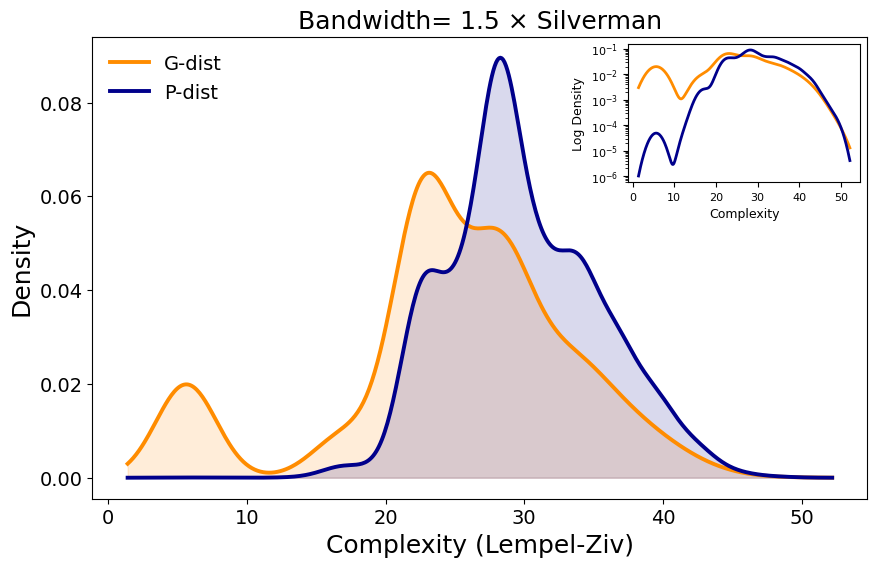


Plot saved to: plots/Plot_A_Circ.png


In [58]:
#!/usr/bin/env python3
"""
Plot LZ Complexity Distribution for Circadian Rhythm Model
Shows G-dist (rand) vs P-dist (0-mut) using Kernel Density Estimation
with DOUBLE Silverman's bandwidth (2 × Silverman).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

bandwidth_multiplier = 1.5

# ========== CONFIGURATION ==========
base_dir = './plot_a_files'
output_dir = './plots'
output_name = 'Plot_A_Circ.png'
phenotype_length = 50
# ===================================

file_path_rand = Path(base_dir) / "t0to50_table.txt"
file_path_0_mut = Path(base_dir) / "compiled_0mut.txt"

def read_and_debug_file(file_path, dataset_name):
    """Read file and handle different header formats"""
    print(f"\nReading {dataset_name} from: {file_path}")
    
    if not os.path.exists(file_path):
        print(f"ERROR: File not found: {file_path}")
        return None
    
    try:
        df = pd.read_csv(file_path, sep='\t')
        print(f"✓ Successfully loaded {len(df)} rows")
        
        first_col = df.columns[0]
        if first_col.startswith('#'):
            df = pd.read_csv(
                file_path,
                sep='\t',
                skiprows=1,
                names=['file_number', 'genotype_raw',
                       'phenotype_binary', 'complexity_entropy']
            )
            print(f"✓ Re-read with proper column names: {len(df)} rows")
        
        return df
        
    except Exception as e:
        print(f"ERROR reading {dataset_name}: {e}")
        return None

# Read datasets
df_rand = read_and_debug_file(file_path_rand, "rand")
df_0_mut = read_and_debug_file(file_path_0_mut, "0_mut")

datasets = [
    (df_rand, "rand"),
    (df_0_mut, "0_mut")
]

valid_datasets = [(df, name) for df, name in datasets if df is not None]

if len(valid_datasets) == 0:
    raise ValueError("No valid datasets found")

print(f"\nProceeding with {len(valid_datasets)} valid datasets...")

def process_dataset(df, name):
    """Process a single dataset"""
    df['phenotype_binary'] = df['phenotype_binary'].astype(str)
    df['phenotype_length'] = df['phenotype_binary'].str.len()
    df_filtered = df[df['phenotype_length'] == phenotype_length]
    
    complexities = df_filtered['complexity_entropy'].values
    mean_complexity = complexities.mean()
    
    print(f"{name}: {len(complexities)} samples, mean={mean_complexity:.2f}")
    
    return complexities, mean_complexity


# ===============================
# KDE function (DOUBLE Silverman bandwidth)
# ===============================
def kde_curve(data, name=None):

    n_raw = len(data)

    kde = gaussian_kde(data, bw_method='silverman')
    silverman_factor = kde.factor

    # Apply multiplier
    kde.set_bandwidth(bw_method=silverman_factor * bandwidth_multiplier)

    if name:
        print(f"{name}:")
        print(f"  Silverman factor = {silverman_factor:.6f}")
        print(f"  Adjusted factor  = {kde.factor:.6f}")

    x_min, x_max = data.min(), data.max()
    x_range = x_max - x_min

    x = np.linspace(
        x_min - 0.1 * x_range,
        x_max + 0.1 * x_range,
        500
    )

    y = kde(x)

    return x, y


# Process datasets
datasets_processed = {}
mean_complexities = {}

for df, name in valid_datasets:
    complexities, mean_val = process_dataset(df, name)
    datasets_processed[name] = complexities
    mean_complexities[name] = mean_val

# Print mean comparison
print("\nMean Complexity:")
if 'rand' in mean_complexities:
    print(f"  G-dist (rand): {mean_complexities['rand']:.2f}")
if '0_mut' in mean_complexities:
    print(f"  P-dist (0-mut): {mean_complexities['0_mut']:.2f}")
if 'rand' in mean_complexities and '0_mut' in mean_complexities:
    diff = mean_complexities['0_mut'] - mean_complexities['rand']
    print(f"  Difference (P - G): {diff:.2f}")

# Colors
colors = {
    'rand': '#FF8C00',
    '0_mut': 'darkblue'
}

labels = {
    'rand': 'G-dist',
    '0_mut': 'P-dist'
}

# Create output directory
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

print("\nKDE Bandwidth Information:")

# ---- Main plot ----
for name, complexities in datasets_processed.items():
    x, y = kde_curve(complexities, name=labels[name])
    ax.plot(x, y, lw=2.8, color=colors[name], label=labels[name])
    ax.fill_between(x, y, color=colors[name], alpha=0.15)

ax.set_xlabel('Complexity (Lempel-Ziv)', fontsize=18)
ax.set_ylabel('Density', fontsize=18)
ax.set_title(f'Bandwidth= {bandwidth_multiplier:.1f} × Silverman', fontsize=18)
ax.legend(frameon=False, fontsize=14, loc='upper left')
ax.tick_params(labelsize=14)

# ---- Inset (log y) ----
axins = inset_axes(ax, width="30%", height="30%", loc='upper right')

for name, complexities in datasets_processed.items():
    x, y = kde_curve(complexities)
    axins.plot(x, y, lw=2.0, color=colors[name])

axins.set_yscale('log')
axins.set_xlabel('Complexity', fontsize=9)
axins.set_ylabel('Log Density', fontsize=9)
axins.tick_params(labelsize=8)

# Save
output_path = Path(output_dir) / output_name
plt.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to: {output_path}")


sampled data (N=1000)


--- SAMPLE STATS ---
G sample N = 1000
P raw N = 5369
G sample mean = 24.8540
P mean = 29.8766
Difference (P - G sample) = 5.0226

--- BANDWIDTHS (Sampled) ---

G-dist (Sampled):
  Silverman bandwidth = 0.266065

P-dist:
  Silverman bandwidth = 0.190112


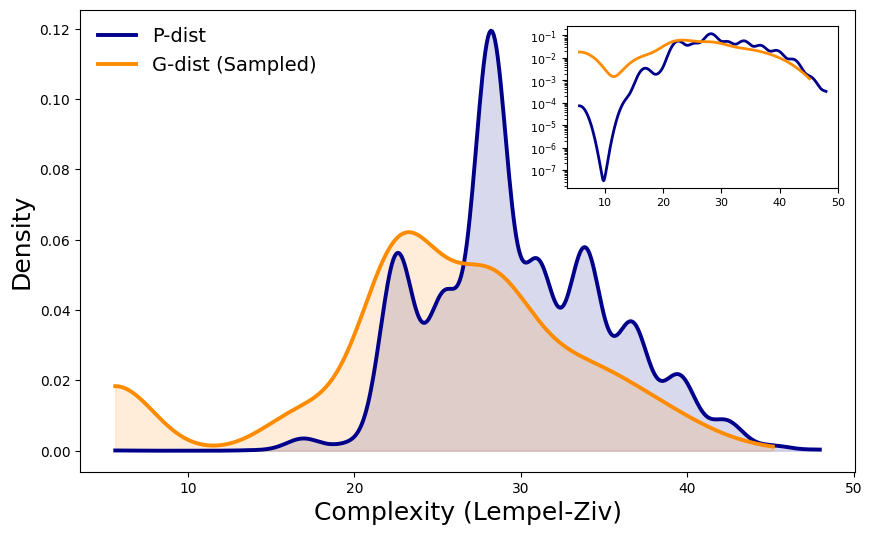


Saved: Plot_A_Circ_SAMPLED.png


In [49]:
#!/usr/bin/env python3
"""
Circadian Rhythm Model — SAMPLED KDE
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import gaussian_kde
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ========== CONFIGURATION ==========
base_dir = './plot_a_files'
output_dir = './plots'
output_name = 'Plot_A_Circ_SAMPLED.png'
phenotype_length = 50
sample_size = 1000   # change to 1_000_000 if desired
# ===================================

file_path_rand = Path(base_dir) / "t0to50_table.txt"
file_path_0_mut = Path(base_dir) / "compiled_0mut.txt"

# ---------- Load ----------
df_rand = pd.read_csv(file_path_rand, sep='\t')
df_0_mut = pd.read_csv(file_path_0_mut, sep='\t')

def process_dataset(df):
    df['phenotype_binary'] = df['phenotype_binary'].astype(str)
    df = df[df['phenotype_binary'].str.len() == phenotype_length]
    return df['complexity_entropy'].values

g_raw = process_dataset(df_rand)
p_raw = process_dataset(df_0_mut)

# ---------- Sample ----------
rng = np.random.default_rng(42)
g_sample = rng.choice(g_raw, size=sample_size, replace=False)

print("\n--- SAMPLE STATS ---")
print(f"G sample N = {len(g_sample)}")
print(f"P raw N = {len(p_raw)}")
print(f"G sample mean = {g_sample.mean():.4f}")
print(f"P mean = {p_raw.mean():.4f}")
print(f"Difference (P - G sample) = {p_raw.mean() - g_sample.mean():.4f}")

# ---------- KDE ----------
def kde_raw(data, name):
    kde = gaussian_kde(data, bw_method='silverman')
    print(f"\n{name}:")
    print(f"  Silverman bandwidth = {kde.factor:.6f}")
    x = np.linspace(data.min(), data.max(), 500)
    y = kde(x)
    return x, y

print("\n--- BANDWIDTHS (Sampled) ---")
x_g, y_g = kde_raw(g_sample, "G-dist (Sampled)")
x_p, y_p = kde_raw(p_raw, "P-dist")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(x_p, y_p, lw=2.8, color="darkblue", label="P-dist")
ax.fill_between(x_p, y_p, color="darkblue", alpha=0.15)

ax.plot(x_g, y_g, lw=2.8, color="#FF8C00", label="G-dist (Sampled)")
ax.fill_between(x_g, y_g, color="#FF8C00", alpha=0.15)

ax.set_xlabel("Complexity (Lempel-Ziv)", fontsize=18)
ax.set_ylabel("Density", fontsize=18)
ax.legend(frameon=False, fontsize=14, loc="upper left")

# ---- Inset ----
axins = inset_axes(ax, width="35%", height="35%", loc="upper right", borderpad=1.2)
axins.plot(x_p, y_p, lw=2.0, color="darkblue")
axins.plot(x_g, y_g, lw=2.0, color="#FF8C00")
axins.set_yscale("log")
axins.tick_params(labelsize=8)

Path(output_dir).mkdir(exist_ok=True)
plt.savefig(Path(output_dir)/output_name, dpi=200, bbox_inches='tight')
plt.show()

print(f"\nSaved: {output_name}")


### Old Histograms


Reading rand from: plot_a_files/t0to50_table.txt
✓ Successfully loaded 10000 rows
Columns found: ['file_number', 'genotype_raw', 'phenotype_binary', 'complexity_entropy']

Reading 0_mut from: plot_a_files/compiled_0mut.txt
✓ Successfully loaded 5369 rows
Columns found: ['file_number', 'genotype_raw', 'phenotype_binary', 'complexity_entropy']

Reading 1_mut from: plot_a_files/1mut_0to50_table.txt
✓ Successfully loaded 5369 rows
Columns found: ['file_number', 'genotype_raw', 'phenotype_binary', 'complexity_entropy']

Reading 2_mut from: plot_a_files/2mut_0to50_table.txt
✓ Successfully loaded 5369 rows
Columns found: ['file_number', 'genotype_raw', 'phenotype_binary', 'complexity_entropy']

Proceeding with 4 valid datasets...
rand: 10000 samples, mean=24.90
0_mut: 5369 samples, mean=29.88
1_mut: 5369 samples, mean=29.08
2_mut: 5369 samples, mean=28.57

Plot saved to: plots/Histo_t0to50.png

Plot saved to: plots/Histo_t0to50.png


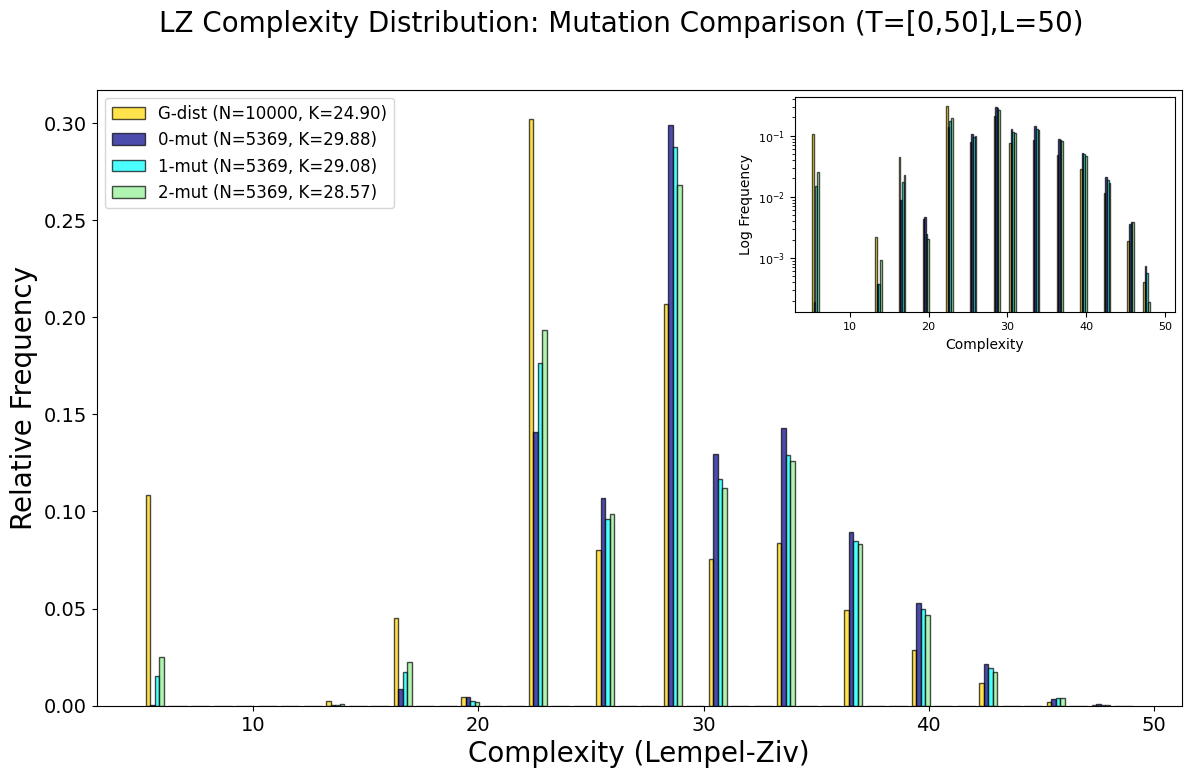

In [24]:
#!/usr/bin/env python3
"""
Plot LZ Complexity Distribution for Circadian Rhythm Model
Shows rand vs 0_mut vs 1_mut vs 2_mut data using the compiled table files.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# ========== CONFIGURATION ==========
base_dir = './plot_a_files'  # Directory containing the 4 table files
output_dir = './plots'  # Directory to save output plot
output_name = 'Histo_t0to50.png'  # Output filename
phenotype_length = 50  # Filter for phenotypes of this length
# ===================================

# Paths to the input files
file_path_rand = Path(base_dir) / "t0to50_table.txt"
file_path_0_mut = Path(base_dir) / "compiled_0mut.txt"
file_path_1_mut = Path(base_dir) / "1mut_0to50_table.txt"
file_path_2_mut = Path(base_dir) / "2mut_0to50_table.txt"

def read_and_debug_file(file_path, dataset_name):
    """Read file and handle different header formats"""
    print(f"\nReading {dataset_name} from: {file_path}")
    
    if not os.path.exists(file_path):
        print(f"ERROR: File not found: {file_path}")
        return None
    
    try:
        # First, try reading normally
        df = pd.read_csv(file_path, sep='\t')
        print(f"✓ Successfully loaded {len(df)} rows")
        print(f"Columns found: {list(df.columns)}")
        
        # Check if first column is a comment header
        first_col = df.columns[0]
        if first_col.startswith('#'):
            print(f"Found comment header: {first_col}")
            # Try reading with skiprows=1 to skip the comment
            df = pd.read_csv(file_path, sep='\t', skiprows=1, 
                           names=['file_number', 'genotype_raw', 'phenotype_binary', 'complexity_entropy'])
            print(f"✓ Re-read with proper column names: {len(df)} rows")
            print(f"New columns: {list(df.columns)}")
        
        # Verify required columns exist
        required_cols = ['file_number', 'genotype_raw', 'phenotype_binary', 'complexity_entropy']
        missing_cols = [col for col in required_cols if col not in df.columns]
        
        if missing_cols:
            print(f"ERROR: Missing columns in {dataset_name}: {missing_cols}")
            return None
        
        return df
        
    except Exception as e:
        print(f"ERROR reading {dataset_name}: {e}")
        return None

# Read all the data with debugging
df_rand = read_and_debug_file(file_path_rand, "rand")
df_0_mut = read_and_debug_file(file_path_0_mut, "0_mut")
df_1_mut = read_and_debug_file(file_path_1_mut, "1_mut")
df_2_mut = read_and_debug_file(file_path_2_mut, "2_mut")

# Check if any files failed to load
datasets = [
    (df_rand, "rand"),
    (df_0_mut, "0_mut"),
    (df_1_mut, "1_mut"),
    (df_2_mut, "2_mut")
]

valid_datasets = [(df, name) for df, name in datasets if df is not None]

if len(valid_datasets) == 0:
    print("ERROR: No valid datasets found. Exiting.")
    raise ValueError("No valid datasets found")

print(f"\nProceeding with {len(valid_datasets)} valid datasets...")

# Process only valid datasets
def process_dataset(df, name):
    """Process a single dataset"""
    # Ensure the 'phenotype_binary' column is treated as strings
    df['phenotype_binary'] = df['phenotype_binary'].astype(str)
    
    # Filter by length
    df['phenotype_length'] = df['phenotype_binary'].str.len()
    df_filtered = df[df['phenotype_length'] == phenotype_length]
    
    complexities = df_filtered['complexity_entropy']
    mean_complexity = complexities.mean()
    
    print(f"{name}: {len(complexities)} samples, mean={mean_complexity:.2f}")
    
    return complexities, len(complexities), mean_complexity

# Process all valid datasets
processed_data = []
for df, name in valid_datasets:
    try:
        complexities, count, mean_val = process_dataset(df, name)
        processed_data.append((complexities, count, mean_val, name))
    except Exception as e:
        print(f"ERROR processing {name}: {e}")

if len(processed_data) == 0:
    print("ERROR: No datasets could be processed. Exiting.")
    raise ValueError("No datasets could be processed")

# Calculate bins from all available data
all_complexities = np.concatenate([data[0] for data in processed_data])
bin_width = 1
bins = np.arange(all_complexities.min() - 0.5,
                 all_complexities.max() + 1.5, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Set up colors for each dataset
colors = {
    'rand': '#FFD700',
    '0_mut': 'darkblue', 
    '1_mut': '#00FFFF',
    '2_mut': '#90EE90'
}

# Create output directory if it doesn't exist
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
bar_width_plot = bin_width / (len(processed_data) + 1)

for i, (complexities, count, mean_val, name) in enumerate(processed_data):
    hist, _ = np.histogram(complexities, bins=bins, density=True)
    
    offset = (i - len(processed_data)/2 + 0.5) * bar_width_plot
    color = colors.get(name, 'gray')
    
    # Change "rand" to "G-dist" and underscores to dashes in legend
    if name == "rand":
        legend_name = "G-dist"
    else:
        legend_name = name.replace("_", "-")
    ax.bar(bin_centers + offset, hist, width=bar_width_plot, 
           color=color, edgecolor='black', alpha=0.7,
           label=f'{legend_name} (N={count}, K={mean_val:.2f})')

# Set titles and labels
fig.suptitle(f'LZ Complexity Distribution: Mutation Comparison (T=[0,50],L=50)', fontsize=20)
ax.set_xlabel('Complexity (Lempel-Ziv)', fontsize=20)
ax.set_ylabel('Relative Frequency', fontsize=20)
ax.legend(fontsize=12, loc='upper left')

# Increase the font size of the axis ticks
ax.tick_params(axis='both', which='major', labelsize=14)

# Add inset with log-scale y-axis
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
axins = inset_axes(ax, width="35%", height="35%", loc='upper right')

for i, (complexities, count, mean_val, name) in enumerate(processed_data):
    hist, _ = np.histogram(complexities, bins=bins, density=True)
    
    offset = (i - len(processed_data)/2 + 0.5) * bar_width_plot
    color = colors.get(name, 'gray')
    
    axins.bar(bin_centers + offset, hist, width=bar_width_plot,
              color=color, edgecolor='black', alpha=0.7)

axins.set_yscale('log')
axins.set_xlabel('Complexity', fontsize=10)
axins.set_ylabel('Log Frequency', fontsize=10)
axins.tick_params(labelsize=8)

# Save the plot
output_path = Path(output_dir) / output_name
plt.savefig(output_path, dpi=200, bbox_inches='tight')
print(f"\nPlot saved to: {output_path}")

Version 2: Only G-dist and P-dist (simplified)


Reading rand from: plot_a_files/t0to50_table.txt
✓ Successfully loaded 10000 rows

Reading 0_mut from: plot_a_files/compiled_0mut.txt
✓ Successfully loaded 5369 rows

Proceeding with 2 valid datasets...
rand: 10000 samples, mean=24.90
0_mut: 5369 samples, mean=29.88


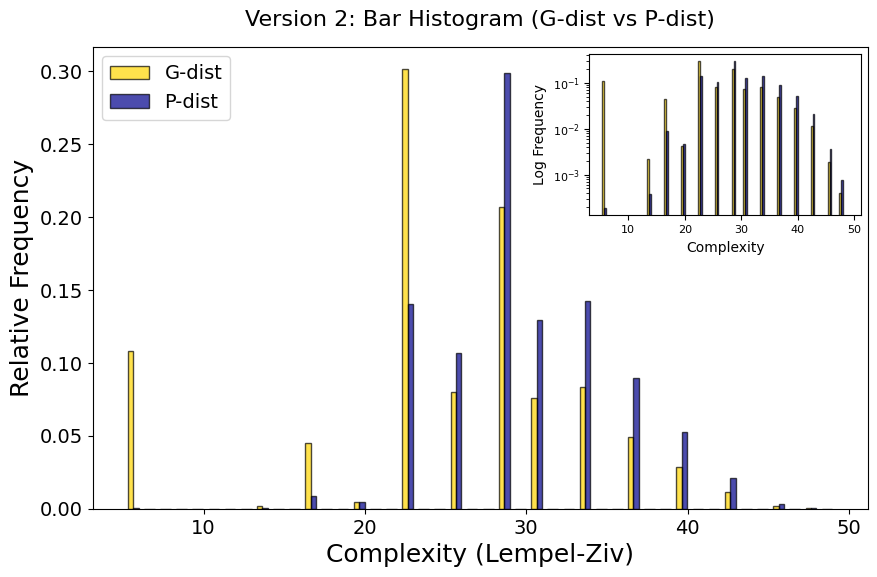


Plot saved to: plots/vers2_Histo_t0to50.png


In [25]:
#!/usr/bin/env python3
"""
Version 2: Simplified plot showing only G-dist and P-dist
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ========== CONFIGURATION ==========
base_dir = './plot_a_files'
output_dir = './plots'
output_name = 'vers2_Histo_t0to50.png'
phenotype_length = 50
# ===================================

# Read only G-dist and P-dist data
file_path_rand = Path(base_dir) / "t0to50_table.txt"
file_path_0_mut = Path(base_dir) / "compiled_0mut.txt"

def read_and_debug_file(file_path, dataset_name):
    """Read file and handle different header formats"""
    print(f"\nReading {dataset_name} from: {file_path}")
    
    if not os.path.exists(file_path):
        print(f"ERROR: File not found: {file_path}")
        return None
    
    try:
        df = pd.read_csv(file_path, sep='\t')
        print(f"✓ Successfully loaded {len(df)} rows")
        
        first_col = df.columns[0]
        if first_col.startswith('#'):
            df = pd.read_csv(file_path, sep='\t', skiprows=1, 
                           names=['file_number', 'genotype_raw', 'phenotype_binary', 'complexity_entropy'])
            print(f"✓ Re-read with proper column names: {len(df)} rows")
        
        return df
        
    except Exception as e:
        print(f"ERROR reading {dataset_name}: {e}")
        return None

# Read only the two datasets
df_rand = read_and_debug_file(file_path_rand, "rand")
df_0_mut = read_and_debug_file(file_path_0_mut, "0_mut")

# Filter to valid datasets
datasets = [
    (df_rand, "rand"),
    (df_0_mut, "0_mut")
]

valid_datasets = [(df, name) for df, name in datasets if df is not None]

if len(valid_datasets) == 0:
    print("ERROR: No valid datasets found. Exiting.")
    raise ValueError("No valid datasets found")

print(f"\nProceeding with {len(valid_datasets)} valid datasets...")

def process_dataset(df, name):
    """Process a single dataset"""
    df['phenotype_binary'] = df['phenotype_binary'].astype(str)
    df['phenotype_length'] = df['phenotype_binary'].str.len()
    df_filtered = df[df['phenotype_length'] == phenotype_length]
    
    complexities = df_filtered['complexity_entropy']
    mean_complexity = complexities.mean()
    
    print(f"{name}: {len(complexities)} samples, mean={mean_complexity:.2f}")
    
    return complexities, len(complexities), mean_complexity

# Process datasets
processed_data = []
for df, name in valid_datasets:
    try:
        complexities, count, mean_val = process_dataset(df, name)
        processed_data.append((complexities, count, mean_val, name))
    except Exception as e:
        print(f"ERROR processing {name}: {e}")

# Calculate bins
all_complexities = np.concatenate([data[0] for data in processed_data])
bin_width = 1
bins = np.arange(all_complexities.min() - 0.5,
                 all_complexities.max() + 1.5, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Set up colors
colors = {
    'rand': '#FFD700',
    '0_mut': 'darkblue'
}

# Create output directory
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bar_width_plot = bin_width / (len(processed_data) + 1)

for i, (complexities, count, mean_val, name) in enumerate(processed_data):
    hist, _ = np.histogram(complexities, bins=bins, density=True)
    
    offset = (i - len(processed_data)/2 + 0.5) * bar_width_plot
    color = colors.get(name, 'gray')
    
    # Rename to G-dist and P-dist
    if name == "rand":
        legend_name = "G-dist"
    elif name == "0_mut":
        legend_name = "P-dist"
    else:
        legend_name = name
    
    ax.bar(bin_centers + offset, hist, width=bar_width_plot, 
           color=color, edgecolor='black', alpha=0.7,
           label=legend_name)

# Set titles and labels
ax.set_title('Version 2: Bar Histogram (G-dist vs P-dist)', fontsize=16, pad=15)
ax.set_xlabel('Complexity (Lempel-Ziv)', fontsize=18)
ax.set_ylabel('Relative Frequency', fontsize=18)
ax.legend(fontsize=14, loc='upper left')
ax.tick_params(axis='both', which='major', labelsize=14)

# Add inset with log-scale y-axis
axins = inset_axes(ax, width="35%", height="35%", loc='upper right')

for i, (complexities, count, mean_val, name) in enumerate(processed_data):
    hist, _ = np.histogram(complexities, bins=bins, density=True)
    
    offset = (i - len(processed_data)/2 + 0.5) * bar_width_plot
    color = colors.get(name, 'gray')
    
    axins.bar(bin_centers + offset, hist, width=bar_width_plot,
              color=color, edgecolor='black', alpha=0.7)

axins.set_yscale('log')
axins.set_xlabel('Complexity', fontsize=10)
axins.set_ylabel('Log Frequency', fontsize=10)
axins.tick_params(labelsize=8)

# Save the plot
output_path = Path(output_dir) / output_name
plt.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"\nPlot saved to: {output_path}")

Version 3: Line plot (binned data)


Reading rand from: plot_a_files/t0to50_table.txt
✓ Successfully loaded 10000 rows

Reading 0_mut from: plot_a_files/compiled_0mut.txt
✓ Successfully loaded 5369 rows

Proceeding with 2 valid datasets...
rand: 10000 samples, mean=24.90
0_mut: 5369 samples, mean=29.88


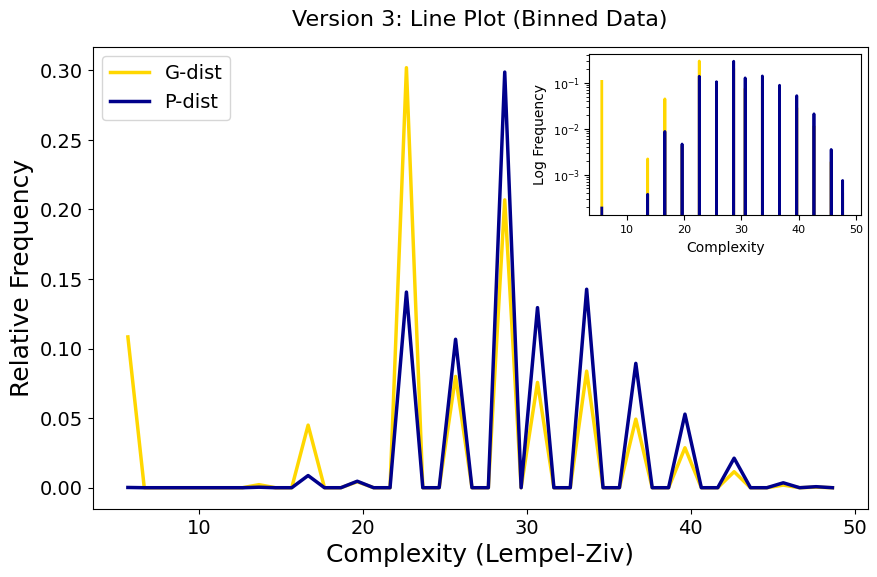


Plot saved to: plots/vers3_lines_Histo_t0to50.png


In [26]:
#!/usr/bin/env python3
"""
Version 3: Line plot connecting histogram bin centers
Shows G-dist and P-dist as lines instead of bars
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ========== CONFIGURATION ==========
base_dir = './plot_a_files'
output_dir = './plots'
output_name = 'vers3_lines_Histo_t0to50.png'
phenotype_length = 50
# ===================================

file_path_rand = Path(base_dir) / "t0to50_table.txt"
file_path_0_mut = Path(base_dir) / "compiled_0mut.txt"

def read_and_debug_file(file_path, dataset_name):
    """Read file and handle different header formats"""
    print(f"\nReading {dataset_name} from: {file_path}")
    
    if not os.path.exists(file_path):
        print(f"ERROR: File not found: {file_path}")
        return None
    
    try:
        df = pd.read_csv(file_path, sep='\t')
        print(f"✓ Successfully loaded {len(df)} rows")
        
        first_col = df.columns[0]
        if first_col.startswith('#'):
            df = pd.read_csv(file_path, sep='\t', skiprows=1, 
                           names=['file_number', 'genotype_raw', 'phenotype_binary', 'complexity_entropy'])
            print(f"✓ Re-read with proper column names: {len(df)} rows")
        
        return df
        
    except Exception as e:
        print(f"ERROR reading {dataset_name}: {e}")
        return None

# Read datasets
df_rand = read_and_debug_file(file_path_rand, "rand")
df_0_mut = read_and_debug_file(file_path_0_mut, "0_mut")

datasets = [
    (df_rand, "rand"),
    (df_0_mut, "0_mut")
]

valid_datasets = [(df, name) for df, name in datasets if df is not None]

if len(valid_datasets) == 0:
    print("ERROR: No valid datasets found. Exiting.")
    raise ValueError("No valid datasets found")

print(f"\nProceeding with {len(valid_datasets)} valid datasets...")

def process_dataset(df, name):
    """Process a single dataset"""
    df['phenotype_binary'] = df['phenotype_binary'].astype(str)
    df['phenotype_length'] = df['phenotype_binary'].str.len()
    df_filtered = df[df['phenotype_length'] == phenotype_length]
    
    complexities = df_filtered['complexity_entropy']
    mean_complexity = complexities.mean()
    
    print(f"{name}: {len(complexities)} samples, mean={mean_complexity:.2f}")
    
    return complexities, len(complexities), mean_complexity

# Process datasets
processed_data = []
for df, name in valid_datasets:
    try:
        complexities, count, mean_val = process_dataset(df, name)
        processed_data.append((complexities, count, mean_val, name))
    except Exception as e:
        print(f"ERROR processing {name}: {e}")

# Calculate bins
all_complexities = np.concatenate([data[0] for data in processed_data])
bin_width = 1
bins = np.arange(all_complexities.min() - 0.5,
                 all_complexities.max() + 1.5, bin_width)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Set up colors
colors = {
    'rand': '#FFD700',
    '0_mut': 'darkblue'
}

# Create output directory
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for i, (complexities, count, mean_val, name) in enumerate(processed_data):
    hist, _ = np.histogram(complexities, bins=bins, density=False)
    hist = hist / count  # Normalize to relative frequency
    
    color = colors.get(name, 'gray')
    
    # Rename to G-dist and P-dist
    if name == "rand":
        legend_name = "G-dist"
    elif name == "0_mut":
        legend_name = "P-dist"
    else:
        legend_name = name
    
    # Plot as a line instead of bars
    ax.plot(bin_centers, hist, color=color, linewidth=2.5, label=legend_name)

# Set titles and labels
ax.set_title('Version 3: Line Plot (Binned Data)', fontsize=16, pad=15)
ax.set_xlabel('Complexity (Lempel-Ziv)', fontsize=18)
ax.set_ylabel('Relative Frequency', fontsize=18)
ax.legend(fontsize=14, loc='upper left')
ax.tick_params(axis='both', which='major', labelsize=14)

# Add inset with log-scale y-axis
axins = inset_axes(ax, width="35%", height="35%", loc='upper right')

for i, (complexities, count, mean_val, name) in enumerate(processed_data):
    hist, _ = np.histogram(complexities, bins=bins, density=False)
    hist = hist / count
    
    color = colors.get(name, 'gray')
    
    # Plot as a line in the inset
    axins.plot(bin_centers, hist, color=color, linewidth=2)

axins.set_yscale('log')
axins.set_xlabel('Complexity', fontsize=10)
axins.set_ylabel('Log Frequency', fontsize=10)
axins.tick_params(labelsize=8)

# Save the plot
output_path = Path(output_dir) / output_name
plt.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"\nPlot saved to: {output_path}")

Version 4: Smooth Density Curves (Gaussian Filtered)


Reading rand from: plot_a_files/t0to50_table.txt
✓ Successfully loaded 10000 rows

Reading 0_mut from: plot_a_files/compiled_0mut.txt
✓ Successfully loaded 5369 rows

Proceeding with 2 valid datasets...
rand: 10000 samples, mean=24.90
0_mut: 5369 samples, mean=29.88


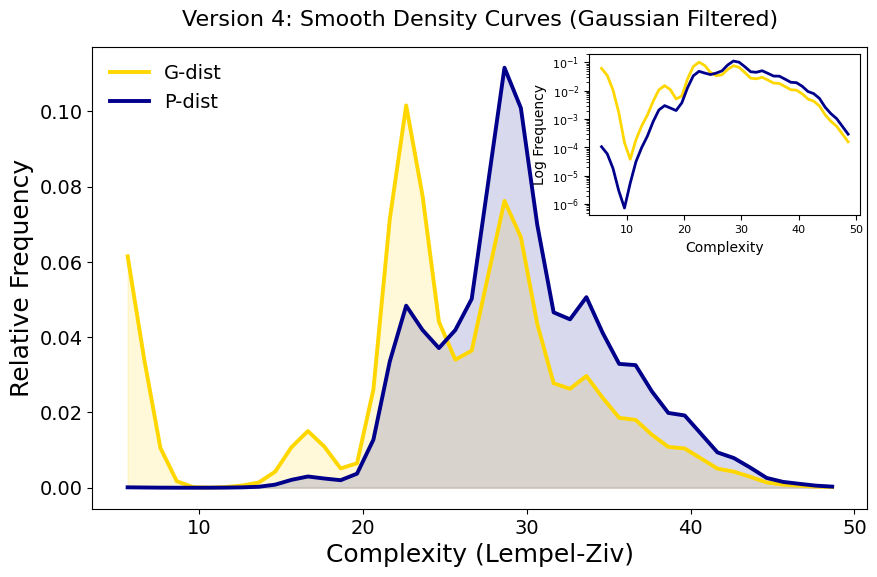


Plot saved to: plots/vers4_density_Histo_t0to50.png


In [27]:
#!/usr/bin/env python3
"""
Version 4: Smooth density curves using Gaussian filtering
Creates publication-quality smooth curves
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter1d
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ========== CONFIGURATION ==========
base_dir = './plot_a_files'
output_dir = './plots'
output_name = 'vers4_density_Histo_t0to50.png'
phenotype_length = 50
num_bins = 45
smooth_sigma = 1.2  # controls smoothness of curves
# ===================================

file_path_rand = Path(base_dir) / "t0to50_table.txt"
file_path_0_mut = Path(base_dir) / "compiled_0mut.txt"

def read_and_debug_file(file_path, dataset_name):
    """Read file and handle different header formats"""
    print(f"\nReading {dataset_name} from: {file_path}")
    
    if not os.path.exists(file_path):
        print(f"ERROR: File not found: {file_path}")
        return None
    
    try:
        df = pd.read_csv(file_path, sep='\t')
        print(f"✓ Successfully loaded {len(df)} rows")
        
        first_col = df.columns[0]
        if first_col.startswith('#'):
            df = pd.read_csv(file_path, sep='\t', skiprows=1, 
                           names=['file_number', 'genotype_raw', 'phenotype_binary', 'complexity_entropy'])
            print(f"✓ Re-read with proper column names: {len(df)} rows")
        
        return df
        
    except Exception as e:
        print(f"ERROR reading {dataset_name}: {e}")
        return None

# Read datasets
df_rand = read_and_debug_file(file_path_rand, "rand")
df_0_mut = read_and_debug_file(file_path_0_mut, "0_mut")

datasets = [
    (df_rand, "rand"),
    (df_0_mut, "0_mut")
]

valid_datasets = [(df, name) for df, name in datasets if df is not None]

if len(valid_datasets) == 0:
    print("ERROR: No valid datasets found. Exiting.")
    raise ValueError("No valid datasets found")

print(f"\nProceeding with {len(valid_datasets)} valid datasets...")

def process_dataset(df, name):
    """Process a single dataset"""
    df['phenotype_binary'] = df['phenotype_binary'].astype(str)
    df['phenotype_length'] = df['phenotype_binary'].str.len()
    df_filtered = df[df['phenotype_length'] == phenotype_length]
    
    complexities = df_filtered['complexity_entropy']
    mean_complexity = complexities.mean()
    
    print(f"{name}: {len(complexities)} samples, mean={mean_complexity:.2f}")
    
    return complexities, len(complexities), mean_complexity

# Process datasets
processed_data = []
for df, name in valid_datasets:
    try:
        complexities, count, mean_val = process_dataset(df, name)
        processed_data.append((complexities, count, mean_val, name))
    except Exception as e:
        print(f"ERROR processing {name}: {e}")

# Calculate bins from all data
all_complexities = np.concatenate([data[0] for data in processed_data])
bins = np.arange(all_complexities.min() - 0.5,
                 all_complexities.max() + 1.5, 1.0)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

def density_curve(data, bins, sigma):
    """Create smooth density curve using Gaussian filtering"""
    hist, _ = np.histogram(data, bins=bins, density=False)
    hist = hist / len(data)  # normalize to relative frequency
    hist = gaussian_filter1d(hist, sigma=sigma)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    return bin_centers, hist

# Set up colors
colors = {
    'rand': '#FFD700',
    '0_mut': 'darkblue'
}

labels = {
    'rand': 'G-dist',
    '0_mut': 'P-dist'
}

# Create output directory
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for complexities, count, mean_val, name in processed_data:
    x, y = density_curve(complexities, bins, smooth_sigma)
    ax.plot(x, y, lw=2.8, color=colors[name], label=labels[name])
    ax.fill_between(x, y, color=colors[name], alpha=0.15)

ax.set_title('Version 4: Smooth Density Curves (Gaussian Filtered)', fontsize=16, pad=15)
ax.set_xlabel('Complexity (Lempel-Ziv)', fontsize=18)
ax.set_ylabel('Relative Frequency', fontsize=18)
ax.legend(frameon=False, fontsize=14, loc='upper left')
ax.tick_params(labelsize=14)

# Add inset with log-scale y-axis
axins = inset_axes(ax, width="35%", height="35%", loc='upper right')

for complexities, count, mean_val, name in processed_data:
    x, y = density_curve(complexities, bins, smooth_sigma)
    axins.plot(x, y, lw=2.0, color=colors[name])

axins.set_yscale('log')
axins.set_xlabel('Complexity', fontsize=10)
axins.set_ylabel('Log Frequency', fontsize=10)
axins.tick_params(labelsize=8)

# Save the plot
output_path = Path(output_dir) / output_name
plt.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"\nPlot saved to: {output_path}")

Version 5: Scatter Plot (Raw Unique Values)


Reading rand from: plot_a_files/t0to50_table.txt
✓ Successfully loaded 10000 rows

Reading 0_mut from: plot_a_files/compiled_0mut.txt
✓ Successfully loaded 5369 rows

Proceeding with 2 valid datasets...
rand: 10000 samples
0_mut: 5369 samples


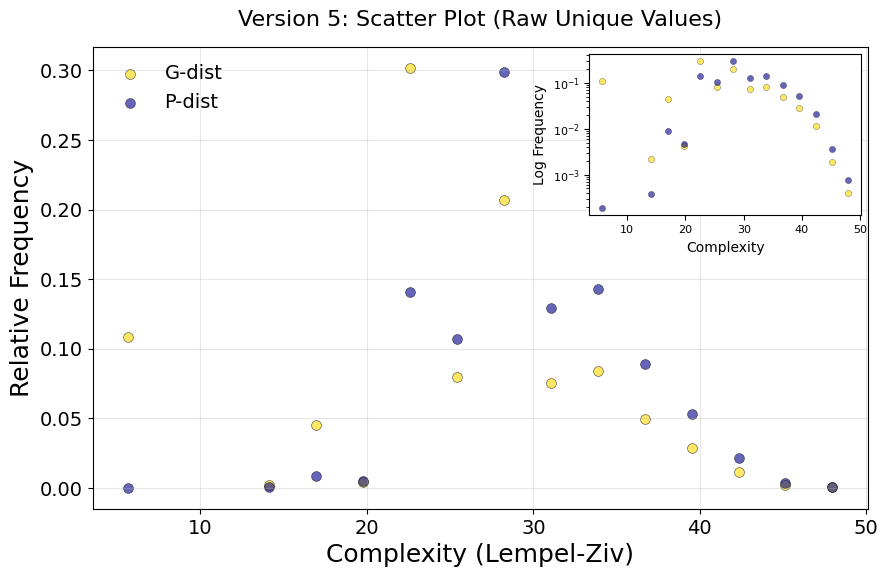


Plot saved to: plots/vers5_scatter_Histo_t0to50.png


In [28]:
"""
Version 5: Scatter plot showing raw unique complexity values
Shows G-dist and P-dist as scatter points without binning
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ========== CONFIGURATION ==========
base_dir = './plot_a_files'
output_dir = './plots'
output_name = 'vers5_scatter_Histo_t0to50.png'
phenotype_length = 50
marker_size = 50  # size of scatter points
marker_alpha = 0.6  # transparency
# ===================================

file_path_rand = Path(base_dir) / "t0to50_table.txt"
file_path_0_mut = Path(base_dir) / "compiled_0mut.txt"

def read_and_debug_file(file_path, dataset_name):
    """Read file and handle different header formats"""
    print(f"\nReading {dataset_name} from: {file_path}")
    
    if not os.path.exists(file_path):
        print(f"ERROR: File not found: {file_path}")
        return None
    
    try:
        df = pd.read_csv(file_path, sep='\t')
        print(f"✓ Successfully loaded {len(df)} rows")
        
        first_col = df.columns[0]
        if first_col.startswith('#'):
            df = pd.read_csv(file_path, sep='\t', skiprows=1, 
                           names=['file_number', 'genotype_raw', 'phenotype_binary', 'complexity_entropy'])
            print(f"✓ Re-read with proper column names: {len(df)} rows")
        
        return df
        
    except Exception as e:
        print(f"ERROR reading {dataset_name}: {e}")
        return None

# Read datasets
df_rand = read_and_debug_file(file_path_rand, "rand")
df_0_mut = read_and_debug_file(file_path_0_mut, "0_mut")

datasets = [
    (df_rand, "rand"),
    (df_0_mut, "0_mut")
]

valid_datasets = [(df, name) for df, name in datasets if df is not None]

if len(valid_datasets) == 0:
    print("ERROR: No valid datasets found. Exiting.")
    raise ValueError("No valid datasets found")

print(f"\nProceeding with {len(valid_datasets)} valid datasets...")

def process_dataset(df, name):
    """Process a single dataset and return complexity values"""
    df['phenotype_binary'] = df['phenotype_binary'].astype(str)
    df['phenotype_length'] = df['phenotype_binary'].str.len()
    df_filtered = df[df['phenotype_length'] == phenotype_length]
    
    complexities = df_filtered['complexity_entropy'].values
    print(f"{name}: {len(complexities)} samples")
    
    return complexities

# Process datasets to get raw complexity values
complexity_data = {}
for df, name in valid_datasets:
    try:
        complexities = process_dataset(df, name)
        complexity_data[name] = complexities
    except Exception as e:
        print(f"ERROR processing {name}: {e}")


def compute_relative_frequencies(data):
    """Count occurrences of each unique value and compute relative frequency"""
    # Filter positive values
    data = data[data > 0]
    
    # Count occurrences
    counts = Counter(data)
    total = len(data)
    
    # Convert to arrays
    x = np.array(sorted(counts.keys()))
    y = np.array([counts[val] / total for val in x])
    
    return x, y


# Set up colors and labels
colors = {
    'rand': '#FFD700',
    '0_mut': 'darkblue'
}

labels = {
    'rand': 'G-dist',
    '0_mut': 'P-dist'
}

# Create output directory
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for name, complexities in complexity_data.items():
    x, y = compute_relative_frequencies(complexities)
    ax.scatter(x, y, s=marker_size, alpha=marker_alpha, color=colors[name], 
               label=labels[name], edgecolors='black', linewidth=0.5)

ax.set_title("Version 5: Scatter Plot (Raw Unique Values)", fontsize=16, pad=15)
ax.set_xlabel("Complexity (Lempel-Ziv)", fontsize=18)
ax.set_ylabel("Relative Frequency", fontsize=18)
ax.legend(frameon=False, fontsize=14, loc='upper left')
ax.tick_params(labelsize=14)
ax.grid(True, alpha=0.3)

# ---- inset (log y) ----
axins = inset_axes(ax, width="35%", height="35%", loc="upper right")

for name, complexities in complexity_data.items():
    x, y = compute_relative_frequencies(complexities)
    # Filter zeros for log scale
    mask = y > 0
    axins.scatter(x[mask], y[mask], s=marker_size*0.4, alpha=marker_alpha, 
                  color=colors[name], edgecolors='black', linewidth=0.3)

axins.set_yscale('log')
axins.set_xlabel("Complexity", fontsize=10)
axins.set_ylabel("Log Frequency", fontsize=10)
axins.tick_params(labelsize=8)

# Save the plot
output_path = Path(output_dir) / output_name
plt.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"\nPlot saved to: {output_path}")

version 6: Line plot connecting raw data points

Version 6: Oscillatory Line Plot (Discrete vs Continuous)


Reading rand from: plot_a_files/t0to50_table.txt
✓ Successfully loaded 10000 rows

Reading 0_mut from: plot_a_files/compiled_0mut.txt
✓ Successfully loaded 5369 rows

Proceeding with 2 valid datasets...
rand: 10000 samples
0_mut: 5369 samples


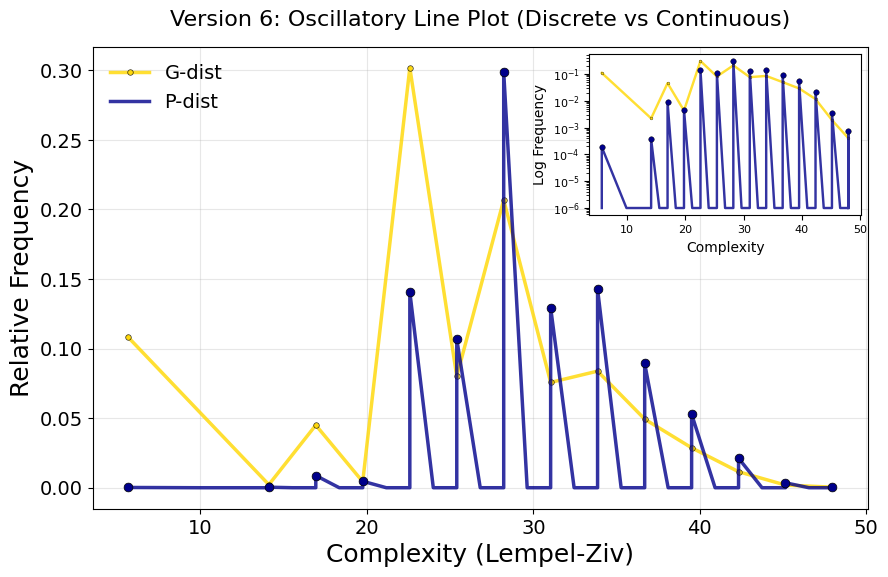


Plot saved to: plots/vers6_oscillatory_Histo_t0to50.png


In [ ]:
#!/usr/bin/env python3
"""
Version 6: Oscillatory line plot
Shows G-dist as continuous and P-dist as discrete spikes
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ========== CONFIGURATION ==========
base_dir = './plot_a_files'
output_dir = './plots'
output_name = 'vers6_oscillatory_Histo_t0to50.png'
phenotype_length = 50
line_width = 2.5
marker_size = 40  # size of markers on the line
# ===================================

file_path_rand = Path(base_dir) / "t0to50_table.txt"
file_path_0_mut = Path(base_dir) / "compiled_0mut.txt"

def read_and_debug_file(file_path, dataset_name):
    """Read file and handle different header formats"""
    print(f"\nReading {dataset_name} from: {file_path}")
    
    if not os.path.exists(file_path):
        print(f"ERROR: File not found: {file_path}")
        return None
    
    try:
        df = pd.read_csv(file_path, sep='\t')
        print(f"✓ Successfully loaded {len(df)} rows")
        
        first_col = df.columns[0]
        if first_col.startswith('#'):
            df = pd.read_csv(file_path, sep='\t', skiprows=1, 
                           names=['file_number', 'genotype_raw', 'phenotype_binary', 'complexity_entropy'])
            print(f"✓ Re-read with proper column names: {len(df)} rows")
        
        return df
        
    except Exception as e:
        print(f"ERROR reading {dataset_name}: {e}")
        return None

# Read datasets
df_rand = read_and_debug_file(file_path_rand, "rand")
df_0_mut = read_and_debug_file(file_path_0_mut, "0_mut")

datasets = [
    (df_rand, "rand"),
    (df_0_mut, "0_mut")
]

valid_datasets = [(df, name) for df, name in datasets if df is not None]

if len(valid_datasets) == 0:
    print("ERROR: No valid datasets found. Exiting.")
    raise ValueError("No valid datasets found")

print(f"\nProceeding with {len(valid_datasets)} valid datasets...")

def process_dataset(df, name):
    """Process a single dataset and return complexity values"""
    df['phenotype_binary'] = df['phenotype_binary'].astype(str)
    df['phenotype_length'] = df['phenotype_binary'].str.len()
    df_filtered = df[df['phenotype_length'] == phenotype_length]
    
    complexities = df_filtered['complexity_entropy'].values
    print(f"{name}: {len(complexities)} samples")
    
    return complexities

# Process datasets to get raw complexity values
complexity_data = {}
for df, name in valid_datasets:
    try:
        complexities = process_dataset(df, name)
        complexity_data[name] = complexities
    except Exception as e:
        print(f"ERROR processing {name}: {e}")


def compute_relative_frequencies(data):
    """Count occurrences of each unique value and compute relative frequency"""
    # Filter positive values
    data = data[data > 0]
    
    # Count occurrences
    counts = Counter(data)
    total = len(data)
    
    # Convert to arrays (sorted by x value)
    x = np.array(sorted(counts.keys()))
    y = np.array([counts[val] / total for val in x])
    
    return x, y


def create_oscillatory_line(x, y):
    """Create oscillatory line that drops to zero between data points"""
    x_new = []
    y_new = []
    
    for i in range(len(x)):
        if i == 0:
            # First point: start from the point itself
            x_new.extend([x[i], x[i]])
            y_new.extend([0, y[i]])
        else:
            # Add zero point between previous and current
            x_mid = (x[i-1] + x[i]) / 2
            x_new.extend([x_mid, x[i], x[i]])
            y_new.extend([0, 0, y[i]])
        
        # Add drop to zero after this point (except for last)
        if i < len(x) - 1:
            x_mid_next = (x[i] + x[i+1]) / 2
            x_new.extend([x_mid_next])
            y_new.extend([0])
        else:
            # Last point: end at the point
            x_new.append(x[i])
            y_new.append(0)
    
    return np.array(x_new), np.array(y_new)


# Set up colors and labels
colors = {
    'rand': '#FFD700',
    '0_mut': 'darkblue'
}

labels = {
    'rand': 'G-dist',
    '0_mut': 'P-dist'
}

# Create output directory
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

for name, complexities in complexity_data.items():
    x, y = compute_relative_frequencies(complexities)
    
    # Create oscillatory line for blue (0_mut) only
    if name == '0_mut':
        x_plot, y_plot = create_oscillatory_line(x, y)
        ax.plot(x_plot, y_plot, color=colors[name], linewidth=line_width, 
                alpha=0.8, label=labels[name])
        # Add markers at the actual data points
        ax.scatter(x, y, s=marker_size, color=colors[name], 
                   edgecolors='black', linewidth=0.5, zorder=5)
    else:
        # Normal line plot for orange (rand)
        ax.plot(x, y, color=colors[name], linewidth=line_width, 
                marker='o', markersize=marker_size/10, markerfacecolor=colors[name],
                markeredgecolor='black', markeredgewidth=0.5, alpha=0.8,
                label=labels[name])

ax.set_title("Version 6: Oscillatory Line Plot (Discrete vs Continuous)", fontsize=16, pad=15)
ax.set_xlabel("Complexity (Lempel-Ziv)", fontsize=18)
ax.set_ylabel("Relative Frequency", fontsize=18)
ax.legend(frameon=False, fontsize=14, loc='upper left')
ax.tick_params(labelsize=14)
ax.grid(True, alpha=0.3)

# ---- inset (log y) ----
axins = inset_axes(ax, width="35%", height="35%", loc="upper right")

for name, complexities in complexity_data.items():
    x, y = compute_relative_frequencies(complexities)
    # Filter zeros for log scale
    mask = y > 0
    
    # Create oscillatory line for blue (0_mut) only
    if name == '0_mut':
        x_plot, y_plot = create_oscillatory_line(x[mask], y[mask])
        # For inset, replace zeros with small value for log scale
        y_plot_log = y_plot.copy()
        y_plot_log[y_plot_log == 0] = 1e-6  # small value for visualization
        axins.plot(x_plot, y_plot_log, color=colors[name], 
                   linewidth=line_width*0.7, alpha=0.8)
        # Add markers at the actual data points
        axins.scatter(x[mask], y[mask], s=marker_size*0.4, color=colors[name],
                      edgecolors='black', linewidth=0.3, zorder=5)
    else:
        axins.plot(x[mask], y[mask], color=colors[name], linewidth=line_width*0.7,
                   marker='o', markersize=marker_size/20, markerfacecolor=colors[name],
                   markeredgecolor='black', markeredgewidth=0.3, alpha=0.8)

axins.set_yscale('log')
axins.set_xlabel("Complexity", fontsize=10)
axins.set_ylabel("Log Frequency", fontsize=10)
axins.tick_params(labelsize=8)

# Save the plot
output_path = Path(output_dir) / output_name
plt.savefig(output_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"\nPlot saved to: {output_path}")